In [ ]:
"""
Empirical suite for: 'Blind recovery of non-abelian group structure from approximate
weight matrices degrades with noise (and with irrep dimension); abelian/cyclic structure survives.'

FIVE clean tests, each with a distinct role:
  T1  exact-case recovery WORKS (positive control: isolates noise, not implementation, as cause)
  T2  recovery DEGRADES with noise (core empirical claim, synthetic S4)
  T3  recovery degrades AT LLM SCALE with real GPT-2 spectrum (realism)
  T4  ABELIAN CONTRAST: cyclic survives noise where non-abelian fails (the dimension argument)
  T5  NATURAL-ABSENCE screen: real token sets carry cyclic, not dihedral, structure
"""
import numpy as np
from itertools import permutations

# ===================== shared S4 machinery =====================
elts=list(permutations(range(4))); n4=len(elts); idx={e:i for i,e in enumerate(elts)}
def mul(a,b): return tuple(a[b[k]] for k in range(4))
def perm_mat(p,s):
    P=np.zeros((s,s)); P[p,np.arange(s)]=1.0; return P
def Lp_s4(g):
    p=np.zeros(n4,dtype=int)
    for i,h in enumerate(elts): p[idx[mul(g,h)]]=i
    return p
L_s4=[perm_mat(Lp_s4(g),n4) for g in elts]

def s4_invariance_defect(Q):
    PB=Q@Q.T
    return float(np.mean([np.linalg.norm(L@PB-PB@L)/(np.linalg.norm(PB)+1e-12) for L in L_s4]))

def recover_center_and_defect(W, tol_rel):
    """Generated-algebra recovery: restrict left action to col(W), compute center (#irreps)
    and the col-space S4-invariance defect. Exact -> center=5, defect=0."""
    U,s,_=np.linalg.svd(W, full_matrices=False)
    rk=int(np.sum(s>tol_rel*s[0])); Q=U[:,:rk]
    r1=Q.T@L_s4[5]@Q; r2=Q.T@L_s4[7]@Q
    def vec(A): return A.reshape(-1)
    seen=[]
    def indep(A):
        if not seen: return np.linalg.norm(A)>1e-12
        B=np.stack([vec(b) for b in seen],1); c,_,_,_=np.linalg.lstsq(B,vec(A),rcond=None)
        return np.linalg.norm(B@c-vec(A))>tol_rel*np.linalg.norm(vec(A))
    frontier=[np.eye(rk)]; gens=[r1,r2]
    for _ in range(80):
        new=[]
        for A in frontier:
            if indep(A):
                seen.append(A)
                for G in gens: new.append(A@G)
        if not new: break
        frontier=new
    ad=len(seen)
    if ad==0: return rk,0,s4_invariance_defect(Q)
    rows=[np.stack([vec(A@G-G@A) for A in seen],1) for G in gens]
    sv=np.linalg.svd(np.vstack(rows),compute_uv=False)
    center=int(np.sum(sv<tol_rel*(sv[0] if len(sv) else 1)))+max(0,ad-len(sv))
    return rk, center, s4_invariance_defect(Q)

def full_regular_W(seed, d=64):
    r=np.random.default_rng(seed)
    A=sum(r.standard_normal()*L_s4[i] for i in range(n4))
    return A@r.standard_normal((n4,d))/np.sqrt(n4)

print("="*70); print("T1: EXACT-CASE RECOVERY WORKS (positive control)"); print("="*70)
W=full_regular_W(0)
rk,center,defect=recover_center_and_defect(W,1e-9)
print(f"  exact full-S4: colrank={rk} (want 24), center={center} (want 5), defect={defect:.2e} (want 0)")
print(f"  -> {'PASS: method recovers S4 exactly; any noisy failure is about NOISE, not the method' if center==5 and defect<1e-9 else 'CHECK'}")

print("\n"+"="*70); print("T2: RECOVERY DEGRADES WITH NOISE (synthetic S4)"); print("="*70)
print(f"  {'noise':>7} {'center(mean±sd)':>18} {'defect(mean±sd)':>20}")
for noise in [0.0,0.02,0.05,0.1,0.2,0.35]:
    cs=[];ds=[]
    for t in range(6):
        r=np.random.default_rng(t); W=full_regular_W(t)
        E=r.standard_normal(W.shape); E=E/np.linalg.norm(E)*np.linalg.norm(W)
        _,c,d=recover_center_and_defect(W+noise*E, max(1e-7,noise*1.3)); cs.append(c); ds.append(d)
    print(f"  {noise:>7.2f} {np.mean(cs):>8.1f}±{np.std(cs):<4.1f}   {np.mean(ds):>8.4f}±{np.std(ds):<6.4f}")
print("  -> center destabilizes, defect climbs 0->1: recovery degrades with noise.")

# T3 and T5 need transformers/GPT-2 -- run in Colab. T4 is self-contained below.
print("\n"+"="*70); print("T4: ABELIAN CONTRAST (cyclic survives, non-abelian fails, same noise)"); print("="*70)
def cyclic_proj(n,k):
    j=np.arange(n); c=np.cos(2*np.pi*k*j/n); s=np.sin(2*np.pi*k*j/n)
    B=np.stack([c,s],1); B,_=np.linalg.qr(B); return B@B.T
def haar(n,rng):
    A=rng.standard_normal((n,n)); Q,R=np.linalg.qr(A); return Q*np.sign(np.diag(R))
def cyclic_recovery_quality(noise, n=12, d=64, trials=6):
    """Cyclic: plant k=1 circle, add noise, test if k=1 still detected above null (rotation-robust)."""
    qual=[]
    for t in range(trials):
        r=np.random.default_rng(t); j=np.arange(n)
        c1=np.cos(2*np.pi*j/n); s1=np.sin(2*np.pi*j/n)
        W0=np.outer(c1,r.standard_normal(d))+np.outer(s1,r.standard_normal(d)); W0/=np.linalg.norm(W0)
        E=r.standard_normal(W0.shape); E=E/np.linalg.norm(E)*np.linalg.norm(W0)
        W=W0+noise*E
        P1=cyclic_proj(n,1)
        f=np.linalg.norm(P1@W,'fro')**2/np.linalg.norm(W,'fro')**2
        ge=1
        for _ in range(400):
            fb=np.linalg.norm(P1@(haar(n,r)@W),'fro')**2/np.linalg.norm(W,'fro')**2
            if fb>=f: ge+=1
        qual.append(ge/401)   # p-value: small = still detected
    return np.mean(qual)
print(f"  {'noise':>7} {'cyclic k=1 p-value':>20} {'non-abelian S4 defect':>22}")
for noise in [0.0,0.05,0.1,0.2,0.35]:
    cyc_p=cyclic_recovery_quality(noise)
    ds=[]
    for t in range(6):
        r=np.random.default_rng(t); W=full_regular_W(t)
        E=r.standard_normal(W.shape); E=E/np.linalg.norm(E)*np.linalg.norm(W)
        _,_,d=recover_center_and_defect(W+noise*E,max(1e-7,noise*1.3)); ds.append(d)
    print(f"  {noise:>7.2f} {cyc_p:>20.4f} {np.mean(ds):>22.4f}")
print("  -> cyclic p stays small (still detected) while non-abelian defect climbs: the")
print("     obstruction is specifically non-abelian, exactly as Schur predicts.")

T1: EXACT-CASE RECOVERY WORKS (positive control)
  exact full-S4: colrank=24 (want 24), center=5 (want 5), defect=1.55e-15 (want 0)
  -> PASS: method recovers S4 exactly; any noisy failure is about NOISE, not the method

T2: RECOVERY DEGRADES WITH NOISE (synthetic S4)
    noise    center(mean±sd)      defect(mean±sd)
     0.00      5.0±0.0      0.0000±0.0000
     0.02     12.2±9.4      0.1959±0.2073
     0.05     17.3±11.8     0.3755±0.2233
     0.10     19.3±17.1     0.6176±0.1032
     0.20     10.3±3.5      0.8163±0.0676
     0.35      2.3±1.4      0.9847±0.0557
  -> center destabilizes, defect climbs 0->1: recovery degrades with noise.

T4: ABELIAN CONTRAST (cyclic survives, non-abelian fails, same noise)
    noise   cyclic k=1 p-value  non-abelian S4 defect
     0.00               0.0025                 0.0000
     0.05               0.0025                 0.3755
     0.10               0.0025                 0.6176
     0.20               0.0025                 0.8163
     0.35   

In [ ]:
import numpy as np
from itertools import permutations

# ============================================================
#  Recovery-difficulty vs group invariants, 11 groups
#  x-axis candidates: max irrep dim, |G|, total gauge, etc.
# ============================================================

def invariance_defect(Q, Lmats):
    PB = Q@Q.T
    return float(np.mean([np.linalg.norm(L@PB - PB@L)/(np.linalg.norm(PB)+1e-12) for L in Lmats]))

def recovery_defect(Lmats, N, noise, d=64, trials=6, seed0=0):
    defs=[]
    for t in range(trials):
        r=np.random.default_rng(seed0+t)
        A=sum(r.standard_normal()*Lmats[i] for i in range(len(Lmats)))
        W0=A@r.standard_normal((N,d))/np.sqrt(N); W0/=np.linalg.norm(W0)
        E=r.standard_normal(W0.shape); E=E/np.linalg.norm(E)*np.linalg.norm(W0)
        U,s,_=np.linalg.svd(W0+noise*E, full_matrices=False)
        tol=max(1e-7, noise*1.3); rk=int(np.sum(s>tol*s[0]))
        defs.append(invariance_defect(U[:,:rk], Lmats))
    return float(np.mean(defs))

# ---------- group builders (regular representations) ----------
def reg_from_elements(els, mul):
    idx={e:i for i,e in enumerate(els)}; n=len(els); L=[]
    for g in els:
        P=np.zeros((n,n))
        for i,h in enumerate(els): P[idx[mul(g,h)],i]=1.0
        L.append(P)
    return L, n

def cyclic(m):
    els=list(range(m)); mul=lambda a,b:(a+b)%m
    L,N=reg_from_elements(els,mul)
    dims=[1,1]+[2]*((m-2)//2) if m%2==0 else [1]+[2]*((m-1)//2)
    return L,N,dims,True

def dihedral(m):
    els=[('r',k) for k in range(m)]+[('s',k) for k in range(m)]
    def mul(a,b):
        ta,ka=a; tb,kb=b
        if ta=='r' and tb=='r': return ('r',(ka+kb)%m)
        if ta=='r' and tb=='s': return ('s',(ka+kb)%m)
        if ta=='s' and tb=='r': return ('s',(ka-kb)%m)
        return ('r',(ka-kb)%m)
    L,N=reg_from_elements(els,mul)
    dims=[1,1,1,1]+[2]*(m//2-1) if m%2==0 else [1,1]+[2]*((m-1)//2)
    return L,N,dims,False

def quaternion8():
    # Q8 = {1,-1,i,-i,j,-j,k,-k}; irreps 1,1,1,1,2
    els=['1','-1','i','-i','j','-j','k','-k']
    tab={}  # multiplication table
    base={('i','i'):'-1',('j','j'):'-1',('k','k'):'-1',
          ('i','j'):'k',('j','k'):'i',('k','i'):'j',
          ('j','i'):'-k',('k','j'):'-i',('i','k'):'-j'}
    def neg(x): return x[1:] if x.startswith('-') else '-'+x
    def mul(a,b):
        sa = -1 if a.startswith('-') else 1; ua=a.lstrip('-')
        sb = -1 if b.startswith('-') else 1; ub=b.lstrip('-')
        s=sa*sb
        if ua=='1': r=ub
        elif ub=='1': r=ua
        else: r=base[(ua,ub)]
        if r.startswith('-'): s*=-1; r=r[1:]
        return r if s==1 else '-'+r
    L,N=reg_from_elements(els,mul)
    return L,N,[1,1,1,1,2],False

def perm_group(k, even_only=False):
    def parity(p): return sum(1 for i in range(len(p)) for j in range(i+1,len(p)) if p[i]>p[j])%2
    els=[p for p in permutations(range(k)) if (not even_only or parity(p)==0)]
    mul=lambda a,b: tuple(a[b[i]] for i in range(k))
    L,N=reg_from_elements(els,mul)
    return L,N

def S3(): L,N=perm_group(3); return L,N,[1,1,2],False
def S4(): L,N=perm_group(4); return L,N,[1,1,2,3,3],False
def S5(): L,N=perm_group(5); return L,N,[1,1,4,4,5,5,6],False
def A4(): L,N=perm_group(4,even_only=True); return L,N,[1,1,1,3],False
def A5(): L,N=perm_group(5,even_only=True); return L,N,[1,3,3,4,5],False

# ---------- 11 groups, ordered cheap -> expensive ----------
GROUP_DEFS=[
    ('Z/6',   cyclic(6)),     # abelian, maxdim 2
    ('S3',    S3()),          # =D3, non-abelian, maxdim 2
    ('D4',    dihedral(4)),   # non-abelian, maxdim 2
    ('Q8',    quaternion8()), # non-abelian, maxdim 2  <-- extra dim-2 non-abelian point
    ('D5',    dihedral(5)),   # non-abelian, maxdim 2
    ('Z/12',  cyclic(12)),    # abelian, maxdim 2
    ('D6',    dihedral(6)),   # non-abelian, maxdim 2  <-- extra dim-2 non-abelian point
    ('A4',    A4()),          # non-abelian, maxdim 3
    ('S4',    S4()),          # non-abelian, maxdim 3
    ('A5',    A5()),          # non-abelian, maxdim 5  (order 60, SLOW)
    ('S5',    S5()),          # non-abelian, maxdim 6  (order 120, SLOW - drop if it hangs)
]

def spearman(x,y):
    rx=np.argsort(np.argsort(x)); ry=np.argsort(np.argsort(y))
    return float(np.corrcoef(rx,ry)[0,1])

print(f"{'group':>6} {'|G|':>4} {'maxdim':>7} {'abelian':>8}  {'defect@0.1':>10} {'defect@0.2':>10}")
rows=[]
for name,(L,N,dims,abel) in GROUP_DEFS:
    # adapt trials/noise cost for big groups
    tr = 4 if N>50 else 6
    d1=recovery_defect(L,N,0.1,trials=tr); d2=recovery_defect(L,N,0.2,trials=tr)
    rows.append({'name':name,'N':N,'dims':dims,'maxdim':max(dims),'abel':abel,'d1':d1,'d2':d2})
    print(f"{name:>6} {N:>4} {max(dims):>7} {str(abel):>8}  {d1:>10.3f} {d2:>10.3f}", flush=True)

print("\n--- which invariant orders recovery difficulty? (Spearman rho with defect@0.2) ---")
maxdim=[r['maxdim'] for r in rows]
order =[r['N'] for r in rows]
gauge =[sum(d*d-1 for d in r['dims']) for r in rows]   # |G|-#irreps
d2=[r['d2'] for r in rows]
print(f"  max irrep dim        : rho = {spearman(maxdim,d2):.3f}")
print(f"  |G| (group order)    : rho = {spearman(order,d2):.3f}")
print(f"  total gauge (|G|-#irr): rho = {spearman(gauge,d2):.3f}")

print("\n--- within-dimension check: at fixed max-irrep-dim, do abelian < non-abelian? ---")
for dim in sorted(set(maxdim)):
    grp=[(r['name'],r['abel'],r['d2']) for r in rows if r['maxdim']==dim]
    print(f"  maxdim={dim}: " + ", ".join(f"{n}({'ab' if a else 'nonab'})={d:.2f}" for n,a,d in grp))
print("\nREAD: if max-irrep-dim rho stays ~0.95+ with 11 groups -> dimension-dominance robust.")
print("Within-dimension lines show the secondary non-abelian effect (abelian should sit lowest).")

 group  |G|  maxdim  abelian  defect@0.1 defect@0.2
   Z/6    6       2     True       0.026      0.078
    S3    6       2    False       0.399      0.462
    D4    8       2    False       0.219      0.378
    Q8    8       2    False       0.011      0.251
    D5   10       2    False       0.373      0.567
  Z/12   12       2     True       0.096      0.237
    D6   12       2    False       0.282      0.496
    A4   12       3    False       0.495      0.664
    S4   24       3    False       0.617      0.828
    A5   60       5    False       0.842      1.019
    S5  120       6    False       1.005      1.119

--- which invariant orders recovery difficulty? (Spearman rho with defect@0.2) ---
  max irrep dim        : rho = 0.855
  |G| (group order)    : rho = 0.855
  total gauge (|G|-#irr): rho = 0.682

--- within-dimension check: at fixed max-irrep-dim, do abelian < non-abelian? ---
  maxdim=2: Z/6(ab)=0.08, S3(nonab)=0.46, D4(nonab)=0.38, Q8(nonab)=0.25, D5(nonab)=0.57, Z/12(ab

In [ ]:
import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# ============================================================
#  CORRECT real-weight symmetry-breaking test:
#  Is the DEVIATION from cyclic equivariance irrep-SELECTIVE (structured breaking)
#  vs an ANISOTROPY-MATCHED null (random token sets from the same embedding)?
# ============================================================

def fourier_projectors(n):
    j=np.arange(n); P={}
    for k in range(n//2+1):
        c=np.cos(2*np.pi*k*j/n); s=np.sin(2*np.pi*k*j/n)
        cols=[c]+([s] if np.linalg.norm(s)>1e-9 else [])
        B=np.stack(cols,1); B,_=np.linalg.qr(B); P[k]=B@B.T
    return P

print("Loading GPT-2...")
model=AutoModelForCausalLM.from_pretrained("gpt2", dtype=torch.float32)
tok=AutoTokenizer.from_pretrained("gpt2")
Emb=model.get_input_embeddings().weight.detach().float().numpy()

def token_rows(words):
    ids=[]
    for w in words:
        c=tok(" "+w,add_special_tokens=False)["input_ids"]
        ids.append(c[0] if len(c)==1 else tok(w,add_special_tokens=False)["input_ids"][0])
    return Emb[ids,:]

MONTHS=["January","February","March","April","May","June","July","August","September","October","November","December"]
DAYS=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

def deviation_selectivity(W, P, nz):
    """After removing k=0 (anisotropy) AND k=1 (the recovered circle), how UNEVEN (selective)
    is the residual energy across the remaining irreps? High variance = structured breaking
    (energy concentrated in specific irreps). Low variance = generic (even spread)."""
    Wc = W - P[0]@W
    dev = Wc - P[1]@Wc
    if np.linalg.norm(dev) < 1e-9: return 0.0
    rem = [k for k in nz if k != 1]
    e = np.array([np.linalg.norm(P[k]@dev,'fro')**2 for k in rem])
    if e.sum() < 1e-12: return 0.0
    e = e/e.sum()
    return float(np.var(e))                    # selectivity statistic

def test_vs_anisotropy_null(target, n, B=5000, seed=0):
    """Null = random n-token sets from the SAME embedding (matches anisotropy, no cyclic structure).
    Tests whether target's deviation is MORE irrep-selective than random sets."""
    P = fourier_projectors(n); nz=[k for k in P if k!=0]
    obs = deviation_selectivity(target, P, nz)
    rng = np.random.default_rng(seed); ge=1; N=Emb.shape[0]
    null_vals=[]
    for _ in range(B):
        idx = rng.choice(N, n, replace=False)
        v = deviation_selectivity(Emb[idx], P, nz)
        null_vals.append(v)
        if v >= obs: ge+=1
    return obs, ge/(B+1), np.mean(null_vals)

# ============================================================
# MAIN TEST: is the deviation in months/days irrep-selective beyond anisotropy?
# ============================================================
print("\n" + "="*64)
print("SYMMETRY-BREAKING TEST: is deviation irrep-SELECTIVE vs anisotropy-matched null?")
print("="*64)
for name, words, n in [("months", MONTHS, 12), ("days", DAYS, 7)]:
    W = token_rows(words)
    obs, p, null_mean = test_vs_anisotropy_null(W, n, seed=0)
    print(f"\n{name} (Z/{n}):")
    print(f"  deviation selectivity = {obs:.5f}")
    print(f"  null mean (random sets) = {null_mean:.5f}")
    print(f"  p = {p:.4f}")
    if p < 0.05:
        print(f"  -> DEVIATION IS IRREP-SELECTIVE (p<0.05): evidence for SYMMETRY BREAKING in real weights")
    else:
        print(f"  -> deviation not more selective than random (p>0.05): NO symmetry-breaking signature")

# ============================================================
# CONTROL: random token sets must NOT be significant (they ARE the null, so ~50% by construction)
# This verifies the test is calibrated: a random set should sit in the middle of the null.
# ============================================================
print("\n" + "="*64)
print("CALIBRATION CHECK: random token sets should give p ~ uniform (not systematically <0.05)")
print("="*64)
import random
pool=["table","quantum","forest","ocean","ladder","whisper","granite","melody","corner",
      "velvet","thunder","pencil","river","copper","silent","garden","matrix","feather",
      "bottle","window","candle","mirror","pillow","basket"]
ps=[]
for trial in range(6):
    random.seed(trial); words=random.sample(pool, 12); n=12
    W=token_rows(words)
    obs, p, nm = test_vs_anisotropy_null(W, n, seed=trial)
    ps.append(p)
    print(f"  random set {trial}: selectivity={obs:.5f}, p={p:.4f}")
print(f"\n  {sum(1 for p in ps if p<0.05)}/6 random sets significant at p<0.05 (expect ~0-1; if many, test miscalibrated)")

# ============================================================
# DIAGNOSTIC: WHICH irreps does the deviation concentrate in? (if significant, this shows the pattern)
# ============================================================
print("\n" + "="*64)
print("DIAGNOSTIC: deviation energy per irrep (the breaking pattern, if any)")
print("="*64)
for name, words, n in [("months", MONTHS, 12), ("days", DAYS, 7)]:
    W = token_rows(words); P = fourier_projectors(n); nz=[k for k in P if k!=0]
    Wc = W - P[0]@W; dev = Wc - P[1]@Wc
    rem=[k for k in nz if k!=1]
    e=np.array([np.linalg.norm(P[k]@dev,'fro')**2 for k in rem]); e=e/e.sum()
    print(f"  {name}: deviation energy by mode {dict(zip(rem, np.round(e,3)))}")

Loading GPT-2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


SYMMETRY-BREAKING TEST: is deviation irrep-SELECTIVE vs anisotropy-matched null?

months (Z/12):
  deviation selectivity = 0.00533
  null mean (random sets) = 0.00207
  p = 0.0002
  -> DEVIATION IS IRREP-SELECTIVE (p<0.05): evidence for SYMMETRY BREAKING in real weights

days (Z/7):
  deviation selectivity = 0.01776
  null mean (random sets) = 0.00028
  p = 0.0002
  -> DEVIATION IS IRREP-SELECTIVE (p<0.05): evidence for SYMMETRY BREAKING in real weights

CALIBRATION CHECK: random token sets should give p ~ uniform (not systematically <0.05)
  random set 0: selectivity=0.00224, p=0.2893
  random set 1: selectivity=0.00169, p=0.8840
  random set 2: selectivity=0.00214, p=0.3899
  random set 3: selectivity=0.00167, p=0.8812
  random set 4: selectivity=0.00205, p=0.5103
  random set 5: selectivity=0.00260, p=0.0438

  1/6 random sets significant at p<0.05 (expect ~0-1; if many, test miscalibrated)

DIAGNOSTIC: deviation energy per irrep (the breaking pattern, if any)
  months: deviation e

In [ ]:
import numpy as np, torch, torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer

print("Loading GPT-2...")
model=AutoModelForCausalLM.from_pretrained("gpt2"); model.eval()
tok=AutoTokenizer.from_pretrained("gpt2")

# ===== FIX 3: untie readout from input embeddings (verified working last run) =====
wte=model.transformer.wte.weight
if wte.data_ptr()==model.lm_head.weight.data_ptr():
    model.lm_head=torch.nn.Linear(wte.shape[1],wte.shape[0],bias=False)
    model.lm_head.weight=torch.nn.Parameter(wte.detach().clone())
assert model.transformer.wte.weight.data_ptr()!=model.lm_head.weight.data_ptr(),"untie failed"
print("[check] readout untied from input embeddings: OK")

Emb=model.transformer.wte.weight.detach().numpy().copy()
MONTHS=["January","February","March","April","May","June","July","August","September","October","November","December"]
ids=[tok(" "+w,add_special_tokens=False)["input_ids"][0] for w in MONTHS]   # first-token id, for embedding surgery

# ===== FIX 1: show tokenization so we KNOW what we're dealing with =====
print("\n[tokenization of each month]")
month_toks={}
for w in MONTHS:
    t=tok(" "+w,add_special_tokens=False)["input_ids"]; month_toks[w]=t
    print(f"  {w:>10}: {len(t)} token(s) {t}")
n_single=sum(1 for w in MONTHS if len(month_toks[w])==1)
print(f"  -> {n_single}/12 months are single-token")

# ===== FIX 1+2: score full month sequence under a list-continuation prompt =====
def seq_logprob(context, target_word):
    """logP(target_word | context), summing over ALL subword tokens of target. Correct for
    multi-token months. Uses the (untied) readout, so input-embedding surgery doesn't corrupt it."""
    ctx_ids=tok(context,return_tensors="pt")["input_ids"]
    tgt_ids=tok(" "+target_word,add_special_tokens=False)["input_ids"]
    total=0.0; cur=ctx_ids
    with torch.no_grad():
        for t in tgt_ids:
            logits=model(cur).logits[0,-1]
            total+=torch.log_softmax(logits,dim=-1)[t].item()
            cur=torch.cat([cur,torch.tensor([[t]])],dim=1)
    return total

# list-continuation: show a run of months, predict the next (cyclic, wrap-around included)
def make_context(start, length=4):
    return " ".join(MONTHS[(start+i)%12] for i in range(length))
TASKS=[(make_context(s,4), MONTHS[(s+4)%12]) for s in range(12)]   # 12 tasks, includes wrap-around

# ===== BASELINE GATE: can the model even do this task? =====
def mean_task_logprob():
    return np.mean([seq_logprob(ctx,tgt) for ctx,tgt in TASKS])

base=mean_task_logprob()
uniform=np.log(1/50257)
print(f"\n[BASELINE GATE]")
print(f"  mean logP(next month | list) = {base:.3f}  (uniform baseline = {uniform:.3f})")
# show a concrete example
ex_ctx,ex_tgt=TASKS[0]
print(f"  example: '{ex_ctx}' -> P('{ex_tgt}') = {np.exp(seq_logprob(ex_ctx,ex_tgt)):.4f}")
if base < -6.0:
    print("  *** MODEL CANNOT DO THIS TASK (near uniform). Impact test would measure noise. STOP. ***")
    print("  Try: longer context, or a model that can do cyclic continuation.")
    import sys; sys.exit()
print("  -> baseline is above noise floor; impact test is VALID. Proceeding.\n")

# ===== de-breaking and control (only reached if baseline passed) =====
def fourier_projectors(n):
    j=np.arange(n); P={}
    for k in range(n//2+1):
        c=np.cos(2*np.pi*k*j/n); s=np.sin(2*np.pi*k*j/n)
        cols=[c]+([s] if np.linalg.norm(s)>1e-9 else [])
        B=np.stack(cols,1); B,_=np.linalg.qr(B); P[k]=B@B.T
    return P
P=fourier_projectors(12)
W=Emb[ids].copy()
W_debroken=(P[0]+P[1])@W
rng=np.random.default_rng(0); rk=int(round(np.trace(np.eye(12)-(P[0]+P[1]))))
Q,_=np.linalg.qr(rng.standard_normal((12,12)))
W_randrm=(np.eye(12)-Q[:,:rk]@Q[:,:rk].T)@W

def set_inputs(M):
    with torch.no_grad():
        for r,mid in enumerate(ids):
            model.transformer.wte.weight[mid]=torch.tensor(M[r],dtype=model.transformer.wte.weight.dtype)

print("="*60); print("IMPACT TEST (baseline passed — numbers are meaningful)"); print("="*60)
set_inputs(W);         o=mean_task_logprob()
set_inputs(W_debroken);d=mean_task_logprob()
set_inputs(W_randrm);  r=mean_task_logprob()
set_inputs(W)  # restore
print(f"  original:                {o:.3f}")
print(f"  deviation removed:       {d:.3f}  (Δ={d-o:+.3f})")
print(f"  random-subspace removed: {r:.3f}  (Δ={r-o:+.3f})")
print(f"\n  KEY GAP (deviation-drop − random-drop) = {(o-d)-(o-r):+.3f}")
print("  >0 & large -> deviation SPECIFICALLY functional (symmetry breaking has impact)")
print("  ~0 -> no specific impact of the breaking")

Loading GPT-2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[check] readout untied from input embeddings: OK

[tokenization of each month]
     January: 1 token(s) [3269]
    February: 1 token(s) [3945]
       March: 1 token(s) [2805]
       April: 1 token(s) [3035]
         May: 1 token(s) [1737]
        June: 1 token(s) [2795]
        July: 1 token(s) [2901]
      August: 1 token(s) [2932]
   September: 1 token(s) [2693]
     October: 1 token(s) [3267]
    November: 1 token(s) [3389]
    December: 1 token(s) [3426]
  -> 12/12 months are single-token

[BASELINE GATE]
  mean logP(next month | list) = -0.061  (uniform baseline = -10.825)
  example: 'January February March April' -> P('May') = 0.9949
  -> baseline is above noise floor; impact test is VALID. Proceeding.

IMPACT TEST (baseline passed — numbers are meaningful)
  original:                -0.061
  deviation removed:       -1.827  (Δ=-1.766)
  random-subspace removed: -9.762  (Δ=-9.701)

  KEY GAP (deviation-drop − random-drop) = -7.935
  >0 & large -> deviation SPECIFICALLY functional

In [ ]:
import numpy as np, torch, torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer

print("Loading GPT-2...")
model=AutoModelForCausalLM.from_pretrained("gpt2"); model.eval()
tok=AutoTokenizer.from_pretrained("gpt2")
wte=model.transformer.wte.weight
if wte.data_ptr()==model.lm_head.weight.data_ptr():
    model.lm_head=torch.nn.Linear(wte.shape[1],wte.shape[0],bias=False)
    model.lm_head.weight=torch.nn.Parameter(wte.detach().clone())
assert model.transformer.wte.weight.data_ptr()!=model.lm_head.weight.data_ptr()
print("[check] readout untied: OK")

Emb=model.transformer.wte.weight.detach().numpy().copy()
MONTHS=["January","February","March","April","May","June","July","August","September","October","November","December"]
ids=[tok(" "+w,add_special_tokens=False)["input_ids"][0] for w in MONTHS]

def fourier_projectors(n):
    j=np.arange(n); P={}
    for k in range(n//2+1):
        c=np.cos(2*np.pi*k*j/n); s=np.sin(2*np.pi*k*j/n)
        cols=[c]+([s] if np.linalg.norm(s)>1e-9 else [])
        B=np.stack(cols,1); B,_=np.linalg.qr(B); P[k]=B@B.T
    return P
P=fourier_projectors(12)
W=Emb[ids].copy()

circle=(P[0]+P[1])@W                       # PRESERVED exactly in all conditions
real_dev=W-circle
nz_ge2=[k for k in P if k>=2]

def randomized_dev(seed):
    r=np.random.default_rng(seed); out=np.zeros_like(W)
    for k in nz_ge2:
        re=np.linalg.norm(P[k]@real_dev,'fro')
        Rk=P[k]@r.standard_normal(W.shape)
        if np.linalg.norm(Rk)>1e-9: out+=Rk/np.linalg.norm(Rk)*re   # match per-mode energy
    return out

# the three conditions (all share the EXACT same circle)
W_actual = circle + real_dev               # = original
W_none   = circle                          # circle only (no deviation)

# ===== self-checks: circle preserved, energy matched =====
def check_circle(Wx,name):
    ok=np.allclose((P[0]+P[1])@Wx, circle, atol=1e-4)
    print(f"  [check] {name}: circle preserved = {ok}"); assert ok

# ===== task: list-continuation next-month, sequence-scored (single-token months here) =====
def make_context(start,length=4): return " ".join(MONTHS[(start+i)%12] for i in range(length))
TASKS=[(make_context(s,4), MONTHS[(s+4)%12]) for s in range(12)]
def seq_logprob(ctx,tgt):
    ci=tok(ctx,return_tensors="pt")["input_ids"]; ti=tok(" "+tgt,add_special_tokens=False)["input_ids"]
    tot=0.0; cur=ci
    with torch.no_grad():
        for t in ti:
            tot+=torch.log_softmax(model(cur).logits[0,-1],dim=-1)[t].item()
            cur=torch.cat([cur,torch.tensor([[t]])],dim=1)
    return tot
def set_inputs(M):
    with torch.no_grad():
        for r,mid in enumerate(ids): model.transformer.wte.weight[mid]=torch.tensor(M[r],dtype=wte.dtype)
def mean_lp(): return np.mean([seq_logprob(c,t) for c,t in TASKS])

print("\n[checks]")
check_circle(W_actual,"actual"); check_circle(W_none,"none")
for s in range(5): check_circle(circle+randomized_dev(s), f"random{s}")

# baseline gate
set_inputs(W_actual); base=mean_lp(); set_inputs(W)
print(f"  [check] baseline mean logP = {base:.3f} (must be > -6 for valid test)"); assert base>-6

# ===== THE SPECIFICITY TEST =====
print("\n"+"="*64)
print("SPECIFICITY: does the ACTUAL deviation help more than RANDOM deviations")
print("of identical per-mode energy (circle held fixed in all)?")
print("="*64)
set_inputs(W_actual); a=mean_lp()
set_inputs(W_none);   z=mean_lp()
rand_scores=[]
for s in range(8):
    set_inputs(circle+randomized_dev(s)); rand_scores.append(mean_lp())
set_inputs(W)  # restore
rand_mean=np.mean(rand_scores); rand_std=np.std(rand_scores)
print(f"  actual deviation:        logP = {a:.3f}")
print(f"  randomized deviation:    logP = {rand_mean:.3f} ± {rand_std:.3f}  (8 random draws)")
print(f"  no deviation (circle):   logP = {z:.3f}")
print()
print(f"  actual vs randomized gap = {a-rand_mean:+.3f}")
print("  INTERPRETATION:")
print("  - actual >> randomized (gap >> rand_std) -> the SPECIFIC deviation structure is")
print("    functional; symmetry breaking carries real used information, not just energy.")
print("  - actual ~ randomized -> only the per-mode ENERGY matters, not the specific pattern;")
print("    'breaking is functional' reduces to 'the model needs richness in these modes'.")
print("  - both >> none -> non-circle content matters (we knew); the gap tells us if STRUCTURE does.")

Loading GPT-2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[check] readout untied: OK

[checks]
  [check] actual: circle preserved = True
  [check] none: circle preserved = True
  [check] random0: circle preserved = True
  [check] random1: circle preserved = True
  [check] random2: circle preserved = True
  [check] random3: circle preserved = True
  [check] random4: circle preserved = True
  [check] baseline mean logP = -0.061 (must be > -6 for valid test)

SPECIFICITY: does the ACTUAL deviation help more than RANDOM deviations
of identical per-mode energy (circle held fixed in all)?
  actual deviation:        logP = -0.061
  randomized deviation:    logP = -1.687 ± 0.085  (8 random draws)
  no deviation (circle):   logP = -1.827

  actual vs randomized gap = +1.626
  INTERPRETATION:
  - actual >> randomized (gap >> rand_std) -> the SPECIFIC deviation structure is
    functional; symmetry breaking carries real used information, not just energy.
  - actual ~ randomized -> only the per-mode ENERGY matters, not the specific pattern;
    'breaking

In [ ]:
import numpy as np, torch, torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer

# ============================================================
#  REPLICATION: is the structure-specific functional symmetry breaking
#  consistent across cyclic token sets AND models?
#  (reuses the verified specificity-test core)
# ============================================================

def fourier_projectors(n):
    j=np.arange(n); P={}
    for k in range(n//2+1):
        c=np.cos(2*np.pi*k*j/n); s=np.sin(2*np.pi*k*j/n)
        cols=[c]+([s] if np.linalg.norm(s)>1e-9 else [])
        B=np.stack(cols,1); B,_=np.linalg.qr(B); P[k]=B@B.T
    return P

# cyclic token sets (ordered = the cyclic order)
SETS = {
 "months":  ["January","February","March","April","May","June","July","August","September","October","November","December"],
 "days":    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"],
 "digits":  ["zero","one","two","three","four","five","six","seven","eight","nine"],
 "numerals":["0","1","2","3","4","5","6","7","8","9"],
}
MODELS = ["gpt2", "gpt2-medium", "EleutherAI/pythia-410m"]   # edit as available; add gemma/qwen if you have access

def run_model(model_name):
    print(f"\n{'#'*64}\n# MODEL: {model_name}\n{'#'*64}")
    try:
        model=AutoModelForCausalLM.from_pretrained(model_name); model.eval()
        tok=AutoTokenizer.from_pretrained(model_name)
    except Exception as e:
        print(f"  could not load {model_name}: {e}"); return {}
    # untie readout (architecture-agnostic: find input embeddings + lm head)
    in_emb = model.get_input_embeddings()
    try: out_w = model.get_output_embeddings().weight
    except: out_w = None
    if out_w is not None and in_emb.weight.data_ptr()==out_w.data_ptr():
        new_head=torch.nn.Linear(in_emb.weight.shape[1], in_emb.weight.shape[0], bias=False)
        new_head.weight=torch.nn.Parameter(in_emb.weight.detach().clone())
        model.set_output_embeddings(new_head) if hasattr(model,'set_output_embeddings') else setattr(model,'lm_head',new_head)
    # re-fetch and verify untie
    out_w2 = model.get_output_embeddings().weight if model.get_output_embeddings() else None
    untied = (out_w2 is None) or (in_emb.weight.data_ptr()!=out_w2.data_ptr())
    print(f"  [check] readout untied: {untied}")
    if not untied: print("  WARNING: untie failed for this model; results invalid, skipping."); return {}

    Emb = in_emb.weight.detach().numpy().copy()

    def single_token(word):
        return len(tok(" "+word, add_special_tokens=False)["input_ids"])==1
    def first_id(word):
        return tok(" "+word, add_special_tokens=False)["input_ids"][0]
    def seq_logprob(ctx, tgt):
        ci=tok(ctx,return_tensors="pt")["input_ids"]; ti=tok(" "+tgt,add_special_tokens=False)["input_ids"]
        tot=0.0; cur=ci
        with torch.no_grad():
            for t in ti:
                tot+=torch.log_softmax(model(cur).logits[0,-1],dim=-1)[t].item()
                cur=torch.cat([cur,torch.tensor([[t]])],dim=1)
        return tot

    results={}
    for set_name, words in SETS.items():
        n=len(words)
        P=fourier_projectors(n)
        ids=[first_id(w) for w in words]
        # NOTE: embedding surgery uses first-token id; if multi-token, surgery is on the leading token only.
        multi = [w for w in words if not single_token(w)]
        W=Emb[ids].copy()
        circle=(P[0]+P[1])@W; real_dev=W-circle
        nz=[k for k in P if k>=2]
        def randomized_dev(seed):
            r=np.random.default_rng(seed); out=np.zeros_like(W)
            for k in nz:
                re=np.linalg.norm(P[k]@real_dev,'fro'); Rk=P[k]@r.standard_normal(W.shape)
                if np.linalg.norm(Rk)>1e-9: out+=Rk/np.linalg.norm(Rk)*re
            return out
        # tasks: list-continuation, length 4, cyclic wrap
        TASKS=[(" ".join(words[(s+i)%n] for i in range(4)), words[(s+4)%n]) for s in range(n)]
        def set_inputs(M):
            with torch.no_grad():
                for r,mid in enumerate(ids):
                    model.get_input_embeddings().weight[mid]=torch.tensor(M[r],dtype=in_emb.weight.dtype)
        def mean_lp(): return np.mean([seq_logprob(c,t) for c,t in TASKS])

        # baseline gate
        set_inputs(W); base=mean_lp(); set_inputs(W)
        print(f"\n  [{set_name}] n={n}, multi-token words={multi if multi else 'none'}")
        print(f"    baseline logP={base:.3f}", end="")
        if base < -6.0:
            print("  -> MODEL CANNOT DO THIS SET (skipped, can't measure impact)")
            results[set_name]=None; continue
        print("  (valid)")
        # the specificity test
        set_inputs(W);           a=mean_lp()
        set_inputs(circle);      z=mean_lp()
        rs=[]
        for s in range(8):
            set_inputs(circle+randomized_dev(s)); rs.append(mean_lp())
        set_inputs(W)
        rm, rsd = np.mean(rs), np.std(rs)
        gap = a-rm
        sigmas = gap/(rsd+1e-9)
        results[set_name]=(a,rm,rsd,z,gap,sigmas)
        print(f"    actual={a:.3f}  random={rm:.3f}±{rsd:.3f}  none={z:.3f}")
        print(f"    actual-vs-random gap={gap:+.3f}  ({sigmas:.1f}σ)  -> "
              f"{'STRUCTURE-SPECIFIC functional breaking' if sigmas>3 else 'NOT structure-specific (gap within noise)'}")
    return results

# ============================================================
all_results={}
for m in MODELS:
    all_results[m]=run_model(m)

# ============================================================
# SUMMARY: does the structure-specific functional gap replicate?
# ============================================================
print(f"\n{'='*64}\nREPLICATION SUMMARY (structure-specific gap in σ; >3σ = replicates)\n{'='*64}")
print(f"{'model':>22} | " + " ".join(f"{s:>9}" for s in SETS))
for m, res in all_results.items():
    row=[]
    for s in SETS:
        if res.get(s) is None: row.append("  n/a")
        else: row.append(f"{res[s][5]:>8.1f}σ")
    print(f"{m:>22} | " + " ".join(f"{c:>9}" for c in row))
print("\nREAD: cells >3σ = structure-specific functional breaking replicates there.")
print("If consistently >3σ across sets AND models -> 'property of cyclic structure in LLMs'.")
print("If patchy (some sets/models n/a or <3σ) -> scope the claim to where it holds.")


################################################################
# MODEL: gpt2
################################################################


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  [check] readout untied: True

  [months] n=12, multi-token words=none
    baseline logP=-0.061  (valid)
    actual=-0.061  random=-1.687±0.085  none=-1.827
    actual-vs-random gap=+1.626  (19.2σ)  -> STRUCTURE-SPECIFIC functional breaking

  [days] n=7, multi-token words=none
    baseline logP=-0.805  (valid)
    actual=-0.805  random=-1.117±0.052  none=-1.043
    actual-vs-random gap=+0.312  (6.0σ)  -> STRUCTURE-SPECIFIC functional breaking

  [digits] n=10, multi-token words=none
    baseline logP=-1.557  (valid)
    actual=-1.557  random=-2.248±0.058  none=-2.263
    actual-vs-random gap=+0.691  (12.0σ)  -> STRUCTURE-SPECIFIC functional breaking

  [numerals] n=10, multi-token words=none
    baseline logP=-1.209  (valid)
    actual=-1.209  random=-2.173±0.042  none=-2.297
    actual-vs-random gap=+0.964  (22.7σ)  -> STRUCTURE-SPECIFIC functional breaking

################################################################
# MODEL: gpt2-medium
########################################

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

  [check] readout untied: True

  [months] n=12, multi-token words=none
    baseline logP=-6.414  -> MODEL CANNOT DO THIS SET (skipped, can't measure impact)

  [days] n=7, multi-token words=none
    baseline logP=-8.418  -> MODEL CANNOT DO THIS SET (skipped, can't measure impact)

  [digits] n=10, multi-token words=none
    baseline logP=-3.855  (valid)
    actual=-3.855  random=-4.854±0.433  none=-6.390
    actual-vs-random gap=+0.999  (2.3σ)  -> NOT structure-specific (gap within noise)

  [numerals] n=10, multi-token words=none
    baseline logP=-1.506  (valid)
    actual=-1.506  random=-2.243±0.065  none=-2.211
    actual-vs-random gap=+0.737  (11.4σ)  -> STRUCTURE-SPECIFIC functional breaking

REPLICATION SUMMARY (structure-specific gap in σ; >3σ = replicates)
                 model |    months      days    digits  numerals
                  gpt2 |     19.2σ      6.0σ     12.0σ     22.7σ
           gpt2-medium |     11.7σ      9.5σ     16.4σ     44.7σ
EleutherAI/pythia-410m |    

In [ ]:
# Colab setup
!pip -q install transformers torch scipy numpy huggingface_hub
# For Gemma (gated): authenticate once. GPT-2 needs no auth.
from huggingface_hub import login; login("YOUR_TOKEN_REMOVED")

In [ ]:
import numpy as np, torch, torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer

def fourier_projectors(n):
    j=np.arange(n); P={}
    for k in range(n//2+1):
        c=np.cos(2*np.pi*k*j/n); s=np.sin(2*np.pi*k*j/n)
        cols=[c]+([s] if np.linalg.norm(s)>1e-9 else [])
        B=np.stack(cols,1); B,_=np.linalg.qr(B); P[k]=B@B.T
    return P

SETS = {
 "months":  ["January","February","March","April","May","June","July","August","September","October","November","December"],
 "days":    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"],
 "numerals":["0","1","2","3","4","5","6","7","8","9"],
}
# Gemma 2B requires HF login/access acceptance. If it fails, the script reports and continues.
MODELS = ["gpt2", "google/gemma-2-2b"]

def validate_model(model_name):
    print(f"\n{'#'*64}\n# MODEL: {model_name}\n{'#'*64}")
    try:
        model=AutoModelForCausalLM.from_pretrained(model_name, dtype=torch.float32); model.eval()
        tok=AutoTokenizer.from_pretrained(model_name)
    except Exception as e:
        print(f"  could not load: {e}\n  (Gemma needs `huggingface-cli login` + accepting the model license)"); return
    in_emb=model.get_input_embeddings()
    out=model.get_output_embeddings()
    if out is not None and in_emb.weight.data_ptr()==out.weight.data_ptr():
        h=torch.nn.Linear(in_emb.weight.shape[1],in_emb.weight.shape[0],bias=False)
        h.weight=torch.nn.Parameter(in_emb.weight.detach().clone()); model.set_output_embeddings(h)
    out2=model.get_output_embeddings()
    untied=(out2 is None) or (in_emb.weight.data_ptr()!=out2.weight.data_ptr())
    print(f"  [check] readout untied: {untied}")
    if not untied: print("  untie failed, skipping"); return
    Emb=in_emb.weight.detach().float().numpy().copy()

    def fid(w): return tok(" "+w,add_special_tokens=False)["input_ids"][0]
    def is_single(w): return len(tok(" "+w,add_special_tokens=False)["input_ids"])==1
    def seq_lp(ctx,tgt):
        ci=tok(ctx,return_tensors="pt")["input_ids"]; ti=tok(" "+tgt,add_special_tokens=False)["input_ids"]
        tot=0.0; cur=ci
        with torch.no_grad():
            for t in ti:
                tot+=torch.log_softmax(model(cur).logits[0,-1],dim=-1)[t].item()
                cur=torch.cat([cur,torch.tensor([[t]])],dim=1)
        return tot

    for set_name, words in SETS.items():
        n=len(words); P=fourier_projectors(n); ids=[fid(w) for w in words]
        multi=[w for w in words if not is_single(w)]
        W=Emb[ids].copy(); circle=(P[0]+P[1])@W; dev=W-circle; nz=[k for k in P if k>=2]
        TASKS=[(" ".join(words[(s+i)%n] for i in range(4)), words[(s+4)%n]) for s in range(n)]
        def set_in(M):
            with torch.no_grad():
                for r,mid in enumerate(ids):
                    model.get_input_embeddings().weight[mid]=torch.tensor(M[r],dtype=in_emb.weight.dtype)
        def mlp(): return np.mean([seq_lp(c,t) for c,t in TASKS])
        def rand_dev(seed):
            r=np.random.default_rng(seed); o=np.zeros_like(W)
            for k in nz:
                re=np.linalg.norm(P[k]@dev,'fro'); Rk=P[k]@r.standard_normal(W.shape)
                if np.linalg.norm(Rk)>1e-9: o+=Rk/np.linalg.norm(Rk)*re
            return o

        set_in(W); base=mlp(); set_in(W)
        print(f"\n  [{set_name}] n={n}, multi-token={multi or 'none'}, baseline logP={base:.3f}")
        if base<-6.0: print("    MODEL CANNOT DO SET — skipped"); continue

        # ===== VALIDATION 1: round-trip identity (remove then restore) MUST equal original =====
        set_in(circle+dev); rt=mlp(); set_in(W)
        print(f"    [V1 round-trip identity] logP={rt:.3f} vs baseline {base:.3f} -> "
              f"{'PASS (identical)' if abs(rt-base)<0.01 else 'FAIL (surgery non-idempotent!)'}")

        # ===== VALIDATION 2: monotonic partial removal — should degrade smoothly =====
        print(f"    [V2 monotonic partial removal]")
        prev=None; mono=True
        for f in [0.0,0.25,0.5,0.75,1.0]:
            set_in(W - f*dev); lp=mlp()
            arrow = "" if prev is None else ("ok" if lp<=prev+0.05 else "NON-MONOTONIC")
            if prev is not None and lp>prev+0.05: mono=False
            print(f"      remove {int(f*100):>3}% of deviation: logP={lp:.3f} {arrow}")
            prev=lp
        set_in(W)
        print(f"      -> {'PASS (monotonic degradation)' if mono else 'FAIL (non-monotonic)'}")

        # ===== VALIDATION 3: the main specificity test (actual vs random vs none) =====
        set_in(W); a=mlp(); set_in(circle); z=mlp()
        rs=[ (set_in(circle+rand_dev(s)), mlp())[1] for s in range(8)]; set_in(W)
        rm,rsd=np.mean(rs),np.std(rs); gap=a-rm; sig=gap/(rsd+1e-9)
        print(f"    [V3 specificity] actual={a:.3f} random={rm:.3f}±{rsd:.3f} none={z:.3f}")
        print(f"      gap={gap:+.3f} ({sig:.1f}σ) -> {'STRUCTURE-SPECIFIC' if sig>3 else 'not specific'}")

for m in MODELS: validate_model(m)


################################################################
# MODEL: gpt2
################################################################


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  [check] readout untied: True

  [months] n=12, multi-token=none, baseline logP=-0.061
    [V1 round-trip identity] logP=-0.061 vs baseline -0.061 -> PASS (identical)
    [V2 monotonic partial removal]
      remove   0% of deviation: logP=-0.061 
      remove  25% of deviation: logP=-0.038 ok
      remove  50% of deviation: logP=-0.985 ok
      remove  75% of deviation: logP=-1.914 ok
      remove 100% of deviation: logP=-1.827 NON-MONOTONIC
      -> FAIL (non-monotonic)
    [V3 specificity] actual=-0.061 random=-1.687±0.085 none=-1.827
      gap=+1.626 (19.2σ) -> STRUCTURE-SPECIFIC

  [days] n=7, multi-token=none, baseline logP=-0.805
    [V1 round-trip identity] logP=-0.805 vs baseline -0.805 -> PASS (identical)
    [V2 monotonic partial removal]
      remove   0% of deviation: logP=-0.805 
      remove  25% of deviation: logP=-0.809 ok
      remove  50% of deviation: logP=-0.817 ok
      remove  75% of deviation: logP=-0.891 ok
      remove 100% of deviation: logP=-1.043 ok
      -

config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/24.2k [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

  [check] readout untied: True

  [months] n=12, multi-token=none, baseline logP=-0.249
    [V1 round-trip identity] logP=-0.249 vs baseline -0.249 -> PASS (identical)
    [V2 monotonic partial removal]
      remove   0% of deviation: logP=-0.249 
      remove  25% of deviation: logP=-0.262 ok
      remove  50% of deviation: logP=-0.337 ok
      remove  75% of deviation: logP=-0.715 ok
      remove 100% of deviation: logP=-1.602 ok
      -> PASS (monotonic degradation)


In [ ]:
import numpy as np, torch, torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer

# ============================================================
#  CONFOUND TEST: is the structure-specific functional effect present on a
#  task that CANNOT be solved by sequence statistics (genuine modular arithmetic)?
#  If yes -> the broken-symmetry structure is functional for COMPUTATION.
# ============================================================

MONTHS=["January","February","March","April","May","June","July","August","September","October","November","December"]

# Models that (per prior work) can do modular month arithmetic. GPT-2 CANNOT - do not use it here.
# Try in order; the script gates on baseline accuracy and skips any model that can't do the task.
MODEL_CANDIDATES = ["google/gemma-2-2b", "mistralai/Mistral-7B-v0.3", "meta-llama/Llama-3.2-3B"]

def fourier_projectors(n):
    j=np.arange(n); P={}
    for k in range(n//2+1):
        c=np.cos(2*np.pi*k*j/n); s=np.sin(2*np.pi*k*j/n)
        cols=[c]+([s] if np.linalg.norm(s)>1e-12 else [])
        B=np.stack(cols,1); B,_=np.linalg.qr(B); P[k]=B@B.T
    return P

def run_confound_test(model_name):
    print(f"\n{'='*64}\n# MODEL: {model_name}\n{'='*64}")
    try:
        model=AutoModelForCausalLM.from_pretrained(model_name, dtype=torch.float32); model.eval()
        tok=AutoTokenizer.from_pretrained(model_name)
    except Exception as e:
        print(f"  could not load: {e}"); return None

    # ---- untie readout (so input-embedding surgery doesn't corrupt the unembedding) ----
    in_emb=model.get_input_embeddings()
    out=model.get_output_embeddings()
    if out is not None and in_emb.weight.data_ptr()==out.weight.data_ptr():
        h=torch.nn.Linear(in_emb.weight.shape[1], in_emb.weight.shape[0], bias=False)
        h.weight=torch.nn.Parameter(in_emb.weight.detach().clone()); model.set_output_embeddings(h)
    out2=model.get_output_embeddings()
    untied=(out2 is None) or (in_emb.weight.data_ptr()!=out2.weight.data_ptr())
    print(f"  [check] readout untied: {untied}")
    if not untied: print("  untie failed; skipping (results would be invalid)"); return None

    Emb=in_emb.weight.detach().float().numpy().copy()
    # month token ids (first token); verify single-token where possible
    def first_id(w): return tok(" "+w, add_special_tokens=False)["input_ids"][0]
    ids=[first_id(w) for w in MONTHS]
    multi=[w for w in MONTHS if len(tok(" "+w,add_special_tokens=False)["input_ids"])>1]
    print(f"  [check] multi-token months: {multi if multi else 'none'}")

    # ---- the MODULAR task: vary offset so sequence statistics cannot solve it ----
    # prompt format; we score which month gets highest probability among the 12 month tokens
    def make_prompt(start_idx, offset):
        return f"{MONTHS[start_idx]} plus {offset} months is"
    PAIRS=[(s,o) for s in range(12) for o in range(1,12)]   # 132 genuine modular problems

    def predicted_month(prompt):
        """Return index of the month token with highest next-token probability (restricted to months)."""
        inp=tok(prompt, return_tensors="pt")
        with torch.no_grad(): logits=model(**inp).logits[0,-1]
        month_logits=np.array([logits[mid].item() for mid in ids])
        return int(np.argmax(month_logits))

    def task_accuracy():
        correct=0
        for s,o in PAIRS:
            ans=(s+o)%12
            if predicted_month(make_prompt(s,o))==ans: correct+=1
        return correct/len(PAIRS)

    # ---- BASELINE GATE: model must actually do modular arithmetic ----
    def set_inputs(M):
        with torch.no_grad():
            for r,mid in enumerate(ids):
                model.get_input_embeddings().weight[mid]=torch.tensor(M[r], dtype=in_emb.weight.dtype)
    W=Emb[ids].copy()
    set_inputs(W); base_acc=task_accuracy(); set_inputs(W)
    chance=1/12
    print(f"  [BASELINE GATE] modular-arithmetic accuracy = {base_acc:.3f} (chance = {chance:.3f})")
    if base_acc < 0.4:
        print(f"  *** MODEL CANNOT DO MODULAR ARITHMETIC (acc {base_acc:.2f}). Test is VOID on this model. ***")
        print(f"  (This is expected for GPT-2; the effect can't be tested where the computation doesn't run.)")
        return {"model":model_name, "base_acc":base_acc, "void":True}
    print(f"  -> baseline above threshold; the computation runs, ablation is meaningful. Proceeding.")

    # ---- the ablation: same validated machinery ----
    P=fourier_projectors(12)
    circle=(P[0]+P[1])@W
    real_dev=W-circle
    nz=[k for k in P if k>=2]
    def randomized_dev(seed):
        r=np.random.default_rng(seed); o=np.zeros_like(W)
        for k in nz:
            re=np.linalg.norm(P[k]@real_dev,'fro'); Rk=P[k]@r.standard_normal(W.shape)
            if np.linalg.norm(Rk)>1e-9: o+=Rk/np.linalg.norm(Rk)*re
        return o

    # V1 round-trip identity check (surgery must be clean)
    set_inputs(circle+real_dev); rt_acc=task_accuracy(); set_inputs(W)
    print(f"  [V1 round-trip] acc={rt_acc:.3f} vs baseline {base_acc:.3f} -> {'PASS' if abs(rt_acc-base_acc)<0.02 else 'FAIL (surgery not clean)'}")

    # the three conditions
    set_inputs(W);            acc_actual=task_accuracy()
    set_inputs(circle);       acc_none=task_accuracy()
    rand_accs=[]
    for s in range(5):
        set_inputs(circle+randomized_dev(s)); rand_accs.append(task_accuracy())
    set_inputs(W)
    rm, rsd = np.mean(rand_accs), np.std(rand_accs)

    print(f"\n  MODULAR-ARITHMETIC ACCURACY under ablation:")
    print(f"    actual deviation:      {acc_actual:.3f}")
    print(f"    randomized deviation:  {rm:.3f} ± {rsd:.3f}  (5 seeds, energy-matched per mode)")
    print(f"    no deviation (circle): {acc_none:.3f}")
    print(f"    chance:                {chance:.3f}")
    gap = acc_actual - rm
    print(f"\n  KEY: actual − randomized = {gap:+.3f}")
    print(f"  >0 and large -> the SPECIFIC structure is functional for COMPUTATION (not sequence stats)")
    print(f"  ~0 -> structure not specifically functional for the modular computation")
    return {"model":model_name, "base_acc":base_acc, "actual":acc_actual,
            "random_mean":rm, "random_sd":rsd, "none":acc_none, "gap":gap, "void":False}

results=[]
for m in MODEL_CANDIDATES:
    r=run_confound_test(m)
    if r is not None: results.append(r)
    if r is not None and not r.get("void"): break   # stop at first model that can do the task

print(f"\n{'='*64}\nSUMMARY\n{'='*64}")
for r in results:
    if r.get("void"):
        print(f"  {r['model']}: VOID (can't do modular arithmetic, acc={r['base_acc']:.2f})")
    else:
        print(f"  {r['model']}: baseline={r['base_acc']:.2f}, actual={r['actual']:.2f}, "
              f"random={r['random_mean']:.2f}±{r['random_sd']:.2f}, gap={r['gap']:+.2f}")


# MODEL: google/gemma-2-2b


config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/24.2k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

  [check] readout untied: True
  [check] multi-token months: none


KeyboardInterrupt: 

In [ ]:
"""
CONFOUND-RESOLVING ABLATION on a model that can do month modular arithmetic.
Question: is the structured deviation from the cyclic circle functional for COMPUTATION
(not just sequence statistics)? Tests on Mistral-7B / Llama-3-8B (small models can't compute).

Built to be self-defending: every assumption is CHECKED in-script; any failure aborts with
a clear message rather than silently producing a wrong result. Read the [CHECK] lines first.
"""
import numpy as np, torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MONTHS=["January","February","March","April","May","June","July","August","September","October","November","December"]

# Models that (per Engels et al.) can do modular month arithmetic. Try in order.
MODEL_CANDIDATES = ["mistralai/Mistral-7B-v0.3", "meta-llama/Llama-3.1-8B", "meta-llama/Llama-3.2-3B"]

BASELINE_THRESHOLD = 0.40   # below this, the model can't do the task -> test VOID
N_RANDOM_SEEDS     = 5      # randomized-deviation control seeds (for error bars)

# ----- phrasings; modular-arithmetic accuracy is phrasing-sensitive, take the best -----
PHRASINGS = [
    lambda s,o: f"The month {o} months after {MONTHS[s]} is",
    lambda s,o: f"{o} months after {MONTHS[s]} is",
    lambda s,o: f"{MONTHS[s]} plus {o} months is",
]
PAIRS=[(s,o) for s in range(12) for o in range(1,12)]   # 132 genuine modular problems

def fourier_projectors(n):
    j=np.arange(n); P={}
    for k in range(n//2+1):
        c=np.cos(2*np.pi*k*j/n); s=np.sin(2*np.pi*k*j/n)
        cols=[c]+([s] if np.linalg.norm(s)>1e-12 else [])
        B=np.stack(cols,1); B,_=np.linalg.qr(B); P[k]=B@B.T
    return P

def run(model_name):
    print(f"\n{'='*70}\n# MODEL: {model_name}\n{'='*70}")
    device="cuda" if torch.cuda.is_available() else "cpu"
    if device=="cuda":
        free,total=torch.cuda.mem_get_info()
        print(f"  GPU free/total: {free/1e9:.1f}/{total/1e9:.1f} GB")
        if total/1e9 < 15: print(f"  WARNING: <15GB GPU; a 7-8B model in fp16 may OOM. L4/A100 recommended.")
    try:
        model=AutoModelForCausalLM.from_pretrained(model_name, dtype=torch.float16, device_map=device)
        model.eval()
        tok=AutoTokenizer.from_pretrained(model_name)
    except Exception as e:
        print(f"  COULD NOT LOAD: {e}"); return None

    # ===== HAZARD 2: weight tying. Detect, untie, VERIFY. =====
    in_emb=model.get_input_embeddings()
    out=model.get_output_embeddings()
    tied = (out is not None) and (in_emb.weight.data_ptr()==out.weight.data_ptr())
    if tied:
        h=torch.nn.Linear(in_emb.weight.shape[1], in_emb.weight.shape[0], bias=False).to(device).half()
        with torch.no_grad(): h.weight.copy_(in_emb.weight.detach().clone())
        model.set_output_embeddings(h)
    out2=model.get_output_embeddings()
    untied = (out2 is None) or (in_emb.weight.data_ptr()!=out2.weight.data_ptr())
    print(f"  [CHECK] embeddings were tied: {tied}; untied now: {untied}")
    if not untied:
        print("  *** UNTIE FAILED — input-embedding edits would corrupt the unembedding. ABORTING. ***")
        return None

    # ===== HAZARD 4 + 1: month token ids, decoded for eyeball check, multi-token detection =====
    def ids_for(w): return tok(" "+w, add_special_tokens=False)["input_ids"]
    month_tok_lists=[ids_for(w) for w in MONTHS]
    first_ids=[t[0] for t in month_tok_lists]
    decoded=[tok.decode([fid]) for fid in first_ids]
    multi=[(MONTHS[i], month_tok_lists[i]) for i in range(12) if len(month_tok_lists[i])>1]
    print(f"  [CHECK] first-token decode per month: {list(zip(MONTHS, decoded))[:4]} ...")
    print(f"  [CHECK] multi-token months: {[m[0] for m in multi] if multi else 'none'}")
    MULTI = len(multi)>0
    if MULTI:
        print(f"  -> using FULL continuation logprob scoring (multi-token safe), not first-token argmax")

    # ===== padding for batched scoring (HAZARD 10) =====
    if tok.pad_token is None: tok.pad_token = tok.eos_token
    tok.padding_side="left"

    # ===== HAZARD 3: pristine fp32 copy of the 12 month rows for projection math =====
    Wpristine = in_emb.weight.detach()[first_ids].float().cpu().numpy().copy()   # (12, d) fp32

    def write_month_rows(M_fp32):
        """Write 12 month rows (fp32 numpy) back into the input embedding, in model dtype."""
        with torch.no_grad():
            t=torch.tensor(M_fp32, dtype=in_emb.weight.dtype, device=in_emb.weight.device)
            in_emb.weight[first_ids]=t
    def restore():
        write_month_rows(Wpristine)

    # ===== scoring: returns accuracy over the 132 modular problems =====
    @torch.no_grad()
    def accuracy(prompt_fn, batch_size=16):
        prompts=[prompt_fn(s,o) for s,o in PAIRS]; answers=[(s+o)%12 for s,o in PAIRS]
        correct=0
        for i in range(0,len(prompts),batch_size):
            chunk=prompts[i:i+batch_size]; ans=answers[i:i+batch_size]
            enc=tok(chunk, return_tensors="pt", padding=True).to(device)
            if not MULTI:
                logits=model(**enc).logits[:,-1,:]                       # last pos (left-padded)
                ml=logits[:, first_ids]                                  # (batch,12)
                preds=ml.argmax(dim=-1).cpu().numpy()
            else:
                # full-continuation logprob: score each candidate month's full token sequence
                base=model(**enc).logits[:,-1,:].log_softmax(-1)         # logprob of FIRST answer token
                # approx: rank by first-token logprob then refine top candidates with full seq.
                # For correctness with multi-token, score all 12 by summing logprobs greedily.
                preds=[]
                for b in range(len(chunk)):
                    scores=[]
                    ctx=enc["input_ids"][b][enc["attention_mask"][b].bool()]
                    for mi,mtoks in enumerate(month_tok_lists):
                        seq=torch.cat([ctx, torch.tensor(mtoks,device=device)]).unsqueeze(0)
                        lg=model(seq).logits[0].log_softmax(-1)
                        lp=sum(lg[len(ctx)-1+j, mtoks[j]].item() for j in range(len(mtoks)))
                        scores.append(lp)
                    preds.append(int(np.argmax(scores)))
                preds=np.array(preds)
            correct+=int(np.sum(preds==np.array(ans)))
        return correct/len(prompts)

    # ===== HAZARD 5: BASELINE GATE first, abort if model can't do the task =====
    restore()
    print("\n  [BASELINE GATE] testing whether the model can do modular arithmetic (best of phrasings)...")
    best_acc, best_pf = 0, PHRASINGS[0]
    for pi,pf in enumerate(PHRASINGS):
        restore(); a=accuracy(pf)
        print(f"    phrasing {pi+1} ('{pf(0,5)}'): acc={a:.3f}")
        if a>best_acc: best_acc, best_pf = a, pf
    chance=1/12
    print(f"  best baseline acc = {best_acc:.3f} (chance {chance:.3f})")
    if best_acc < BASELINE_THRESHOLD:
        print(f"  *** MODEL CANNOT DO THE TASK (acc {best_acc:.2f} < {BASELINE_THRESHOLD}). TEST VOID on this model. ***")
        return {"model":model_name,"void":True,"base_acc":best_acc}
    print(f"  -> baseline above threshold; computation runs; ablation is meaningful. Using best phrasing.")

    # ===== build the ablation conditions on the 12 month rows =====
    P=fourier_projectors(12)
    W=Wpristine.copy()
    circle=(P[0]+P[1])@W            # k=0,1 = the circle
    real_dev=W-circle               # the deviation (everything k>=2 plus residual)
    nz=[k for k in P if k>=2]

    def randomized(seed):
        r=np.random.default_rng(seed); o=circle.copy()
        for k in nz:
            re=np.linalg.norm(P[k]@real_dev,'fro'); Rk=P[k]@r.standard_normal(W.shape)
            if np.linalg.norm(Rk)>1e-9: o+=Rk/np.linalg.norm(Rk)*re
        return o

    # ===== HAZARD 6: VERIFY control preserves the circle exactly =====
    test_ctrl=randomized(0)
    circ_diff=np.linalg.norm((P[0]+P[1])@W - (P[0]+P[1])@test_ctrl)
    print(f"\n  [CHECK] control preserves circle (k=0,1): ||diff||={circ_diff:.2e} (must be ~0)")
    if circ_diff>1e-6:
        print("  *** CONTROL PERTURBS THE CIRCLE — confounded. ABORTING. ***"); restore(); return None

    # ===== HAZARD 7: V1 round-trip (remove then restore == baseline) =====
    write_month_rows(circle+real_dev); rt=accuracy(best_pf); restore()
    print(f"  [CHECK V1 round-trip] acc={rt:.3f} vs baseline {best_acc:.3f} -> "
          f"{'PASS' if abs(rt-best_acc)<0.02 else '*** FAIL: surgery not clean, results suspect ***'}")

    # ===== the three conditions (HAZARD 8: restore before each) =====
    restore();                     acc_actual=accuracy(best_pf)
    restore(); write_month_rows(circle);          acc_none=accuracy(best_pf)
    rand=[]
    for s in range(N_RANDOM_SEEDS):
        restore(); write_month_rows(randomized(s)); rand.append(accuracy(best_pf))
    restore()
    rm,rsd=np.mean(rand),np.std(rand)
    gap=acc_actual-rm
    z = gap/rsd if rsd>1e-9 else float('inf')

    print(f"\n  {'='*50}\n  MODULAR-ARITHMETIC ACCURACY under ablation:")
    print(f"    actual deviation:      {acc_actual:.3f}")
    print(f"    randomized deviation:  {rm:.3f} ± {rsd:.3f}  ({N_RANDOM_SEEDS} seeds, energy-matched per mode)")
    print(f"    no deviation (circle): {acc_none:.3f}")
    print(f"    chance:                {chance:.3f}")
    print(f"\n  actual − randomized = {gap:+.3f}   (z ≈ {z:.1f})")
    print(f"  LARGE & positive -> structured deviation is functional for COMPUTATION (confound cleared)")
    print(f"  ~0 -> the SPECIFIC structure is NOT functional for computation (scope claim to sequential)")
    return {"model":model_name,"void":False,"base_acc":best_acc,"actual":acc_actual,
            "rand_mean":rm,"rand_sd":rsd,"none":acc_none,"gap":gap,"z":z,"rt":rt}

results=[]
for m in MODEL_CANDIDATES:
    try:
        r=run(m)
    except torch.cuda.OutOfMemoryError:
        print(f"  *** OOM on {m} — need a larger GPU (L4/A100). ***"); torch.cuda.empty_cache(); continue
    except Exception as e:
        print(f"  *** ERROR on {m}: {e} ***"); continue
    if r is not None:
        results.append(r)
        if not r.get("void"): break   # stop at first model that can do the task AND ran
    torch.cuda.empty_cache()

print(f"\n{'='*70}\nSUMMARY\n{'='*70}")
for r in results:
    if r.get("void"): print(f"  {r['model']}: VOID (baseline {r['base_acc']:.2f} < threshold)")
    else: print(f"  {r['model']}: baseline={r['base_acc']:.2f}  actual={r['actual']:.2f}  "
                f"random={r['rand_mean']:.2f}±{r['rand_sd']:.2f}  gap={r['gap']:+.2f}  z={r['z']:.1f}  "
                f"(V1 rt={r['rt']:.2f})")


# MODEL: mistralai/Mistral-7B-v0.3
  GPU free/total: 41.8/42.4 GB


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  [CHECK] embeddings were tied: False; untied now: True
  [CHECK] first-token decode per month: [('January', 'January'), ('February', 'February'), ('March', 'March'), ('April', 'April')] ...
  [CHECK] multi-token months: none

  [BASELINE GATE] testing whether the model can do modular arithmetic (best of phrasings)...
    phrasing 1 ('The month 5 months after January is'): acc=0.318
    phrasing 2 ('5 months after January is'): acc=0.030
    phrasing 3 ('January plus 5 months is'): acc=0.348
  best baseline acc = 0.348 (chance 0.083)
  *** MODEL CANNOT DO THE TASK (acc 0.35 < 0.4). TEST VOID on this model. ***

# MODEL: meta-llama/Llama-3.1-8B
  GPU free/total: 41.8/42.4 GB


config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


  [CHECK] embeddings were tied: False; untied now: True
  [CHECK] first-token decode per month: [('January', ' January'), ('February', ' February'), ('March', ' March'), ('April', ' April')] ...
  [CHECK] multi-token months: none

  [BASELINE GATE] testing whether the model can do modular arithmetic (best of phrasings)...
    phrasing 1 ('The month 5 months after January is'): acc=0.114
    phrasing 2 ('5 months after January is'): acc=0.015
    phrasing 3 ('January plus 5 months is'): acc=0.500
  best baseline acc = 0.500 (chance 0.083)
  -> baseline above threshold; computation runs; ablation is meaningful. Using best phrasing.

  [CHECK] control preserves circle (k=0,1): ||diff||=7.29e-16 (must be ~0)
  [CHECK V1 round-trip] acc=0.500 vs baseline 0.500 -> PASS

  MODULAR-ARITHMETIC ACCURACY under ablation:
    actual deviation:      0.500
    randomized deviation:  0.500 ± 0.000  (5 seeds, energy-matched per mode)
    no deviation (circle): 0.500
    chance:                0.083

  

In [ ]:
"""
CORRECTED ablation v2. Fixes the leading-space tokenization bug: we now edit the SPACED
month ids (whose circle we measured) and construct prompts so the operand month is
mid-sentence (=> spaced => the row we edit is actually read). Positive control in front.
"""
import numpy as np, torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MONTHS=["January","February","March","April","May","June","July","August","September","October","November","December"]
MODEL="meta-llama/Llama-3.1-8B"
N_RANDOM_SEEDS=5

device="cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading {MODEL}...")
model=AutoModelForCausalLM.from_pretrained(MODEL, dtype=torch.float16).to(device); model.eval()
tok=AutoTokenizer.from_pretrained(MODEL)
if tok.pad_token is None: tok.pad_token=tok.eos_token
tok.padding_side="left"

# untie + verify
in_emb=model.get_input_embeddings(); out=model.get_output_embeddings()
if out is not None and in_emb.weight.data_ptr()==out.weight.data_ptr():
    h=torch.nn.Linear(in_emb.weight.shape[1],in_emb.weight.shape[0],bias=False).to(device).half()
    with torch.no_grad(): h.weight.copy_(in_emb.weight.detach().clone())
    model.set_output_embeddings(h)

# SPACED month ids = the circle we measured
spaced_ids=[tok(" "+w,add_special_tokens=False)["input_ids"][0] for w in MONTHS]
print(f"  [CHECK] spaced month ids: {spaced_ids[:4]} ... decode {[tok.decode([i]) for i in spaced_ids][:4]}")

# ===== PROMPT: operand month must be MID-SENTENCE so it uses the SPACED id we edit =====
# Verify: in this prompt, does the operand month tokenize to the spaced id?
def make_prompt(s,o): return f"Starting from {MONTHS[s]} and counting forward {o} months gives"
test_enc=tok(make_prompt(0,5), add_special_tokens=False)["input_ids"]
print(f"  [CHECK] prompt '{make_prompt(0,5)}'")
print(f"  [CHECK] operand spaced id {spaced_ids[0]} present in prompt? {spaced_ids[0] in test_enc}")
if spaced_ids[0] not in test_enc:
    # try alternative phrasings until the operand month is the spaced id
    for pf in [lambda s,o: f"We have {MONTHS[s]} and add {o} months to get",
               lambda s,o: f"Take {MONTHS[s]} then move {o} months forward to reach",
               lambda s,o: f"From {MONTHS[s]}, {o} months later is"]:
        if spaced_ids[0] in tok(pf(0,5),add_special_tokens=False)["input_ids"]:
            make_prompt=pf; print(f"  [CHECK] switched to: '{make_prompt(0,5)}' (operand is spaced id)"); break
    else:
        print("  *** could not find a prompt where operand month uses the spaced id; STOP and tell me ***")
        raise SystemExit

PAIRS=[(s,o) for s in range(12) for o in range(1,12)]

def write_rows(ids, M_fp32):
    emb=model.get_input_embeddings().weight
    t=torch.tensor(M_fp32, dtype=emb.dtype, device=emb.device)
    with torch.no_grad(): emb.data.index_copy_(0, torch.tensor(ids,device=emb.device), t)
    back=emb.data[ids].float().cpu().numpy()
    assert np.abs(back-M_fp32).max()<1e-2, "write did not land"

Wpristine=model.get_input_embeddings().weight.detach()[spaced_ids].float().cpu().numpy().copy()
def restore(): write_rows(spaced_ids, Wpristine)

@torch.no_grad()
def accuracy(batch_size=16):
    prompts=[make_prompt(s,o) for s,o in PAIRS]; answers=[(s+o)%12 for s,o in PAIRS]
    correct=0
    for i in range(0,len(prompts),batch_size):
        chunk=prompts[i:i+batch_size]; ans=answers[i:i+batch_size]
        enc=tok(chunk,return_tensors="pt",padding=True).to(device)
        logits=model(**enc).logits[:,-1,:]
        preds=logits[:,spaced_ids].argmax(-1).cpu().numpy()   # score answer among spaced month ids
        correct+=int(np.sum(preds==np.array(ans)))
    return correct/len(prompts)

restore(); base=accuracy()
print(f"\n  baseline acc = {base:.3f} (chance {1/12:.3f})")
if base < 0.40:
    print(f"  *** baseline below 0.40 on this prompt; the computation isn't running here. ***")
    print(f"  (Try reporting baseline across a few phrasings before giving up; tell me the numbers.)")
    raise SystemExit

# ===== POSITIVE CONTROL: zero operand rows -> accuracy MUST collapse (now hits the RIGHT rows) =====
write_rows(spaced_ids, np.zeros_like(Wpristine)); acc_zero=accuracy(); restore()
print(f"  [POS-CONTROL] zeroed operand month rows -> acc={acc_zero:.3f} (was {base:.3f})")
if abs(acc_zero-base) < 0.05:
    print("  *** POS-CONTROL FAILED again: still not reading edited rows. STOP — send me this output. ***")
    raise SystemExit
print(f"  -> POS-CONTROL PASSED: edits are LIVE (zeroing collapsed accuracy). Proceeding.\n")

# ===== ablation =====
def fourier_projectors(n):
    j=np.arange(n); P={}
    for k in range(n//2+1):
        c=np.cos(2*np.pi*k*j/n); s=np.sin(2*np.pi*k*j/n)
        cols=[c]+([s] if np.linalg.norm(s)>1e-12 else [])
        B=np.stack(cols,1); B,_=np.linalg.qr(B); P[k]=B@B.T
    return P
P=fourier_projectors(12); W=Wpristine.copy()
circle=(P[0]+P[1])@W; real_dev=W-circle; nz=[k for k in P if k>=2]
def randomized(seed):
    r=np.random.default_rng(seed); o=circle.copy()
    for k in nz:
        re=np.linalg.norm(P[k]@real_dev,'fro'); Rk=P[k]@r.standard_normal(W.shape)
        if np.linalg.norm(Rk)>1e-9: o+=Rk/np.linalg.norm(Rk)*re
    return o
print(f"  [CHECK] control preserves circle: {np.linalg.norm((P[0]+P[1])@W-(P[0]+P[1])@randomized(0)):.2e}")

# V1 round-trip (now meaningful because edits are live)
write_rows(spaced_ids, circle+real_dev); rt=accuracy(); restore()
print(f"  [CHECK V1] round-trip acc={rt:.3f} vs baseline {base:.3f} -> {'PASS' if abs(rt-base)<0.02 else 'FAIL'}")

restore(); acc_actual=accuracy()
write_rows(spaced_ids, circle); acc_none=accuracy(); restore()
rand=[]
for s in range(N_RANDOM_SEEDS):
    write_rows(spaced_ids, randomized(s)); rand.append(accuracy()); restore()
rm,rsd=np.mean(rand),np.std(rand); gap=acc_actual-rm; z=gap/rsd if rsd>1e-9 else float('inf')

print(f"\n  {'='*50}\n  MODULAR-ARITHMETIC ACCURACY under ablation:")
print(f"    actual deviation:      {acc_actual:.3f}")
print(f"    randomized deviation:  {rm:.3f} ± {rsd:.3f}")
print(f"    no deviation (circle): {acc_none:.3f}")
print(f"    chance:                {1/12:.3f}")
print(f"    random-seed values:    {[round(x,3) for x in rand]}  <- MUST vary now")
print(f"\n  actual − randomized = {gap:+.3f}  (z ≈ {z:.1f})")
print(f"  actual − circle-only = {acc_actual-acc_none:+.3f}")

Loading meta-llama/Llama-3.1-8B...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  [CHECK] spaced month ids: [6186, 7552, 5587, 5936] ... decode [' January', ' February', ' March', ' April']
  [CHECK] prompt 'Starting from January and counting forward 5 months gives'
  [CHECK] operand spaced id 6186 present in prompt? True

  baseline acc = 0.235 (chance 0.083)
  *** baseline below 0.40 on this prompt; the computation isn't running here. ***
  (Try reporting baseline across a few phrasings before giving up; tell me the numbers.)


SystemExit: 

In [ ]:
"""
Ablation v3. Ablate the rows the computation READS: the good prompt (0.500 baseline) reads
the operand from UNSPACED month rows, so we ablate those. Score answers among spaced output
ids. Verify the unspaced circle exists; positive control (zero unspaced rows) must collapse.
"""
import numpy as np, torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MONTHS=["January","February","March","April","May","June","July","August","September","October","November","December"]
MODEL="meta-llama/Llama-3.1-8B"
N_RANDOM_SEEDS=5
GOOD_PROMPT = lambda s,o: f"{MONTHS[s]} plus {o} months is"   # sentence-initial month => UNSPACED id; gave 0.500

device="cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading {MODEL}...")
model=AutoModelForCausalLM.from_pretrained(MODEL, dtype=torch.float16).to(device); model.eval()
tok=AutoTokenizer.from_pretrained(MODEL)
if tok.pad_token is None: tok.pad_token=tok.eos_token
tok.padding_side="left"

in_emb=model.get_input_embeddings(); out=model.get_output_embeddings()
if out is not None and in_emb.weight.data_ptr()==out.weight.data_ptr():
    h=torch.nn.Linear(in_emb.weight.shape[1],in_emb.weight.shape[0],bias=False).to(device).half()
    with torch.no_grad(): h.weight.copy_(in_emb.weight.detach().clone())
    model.set_output_embeddings(h)

# UNSPACED ids = what the good prompt reads (operand); SPACED ids = what we score at output (answer)
unspaced_ids=[tok(w, add_special_tokens=False)["input_ids"][0] for w in MONTHS]   # operand rows to ablate
spaced_ids  =[tok(" "+w, add_special_tokens=False)["input_ids"][0] for w in MONTHS] # answer rows to score
print(f"  [CHECK] unspaced operand ids (ablate): {unspaced_ids[:4]} -> {[tok.decode([i]) for i in unspaced_ids][:4]}")
print(f"  [CHECK] spaced answer ids (score):      {spaced_ids[:4]} -> {[tok.decode([i]) for i in spaced_ids][:4]}")

# verify the operand in the good prompt is the unspaced id
enc0=tok(GOOD_PROMPT(0,5), add_special_tokens=False)["input_ids"]
print(f"  [CHECK] prompt '{GOOD_PROMPT(0,5)}': operand unspaced id {unspaced_ids[0]} present? {unspaced_ids[0] in enc0}")

# ===== VERIFY the UNSPACED month rows carry a circle (else nothing to ablate there) =====
def fourier_projectors(n):
    j=np.arange(n); P={}
    for k in range(n//2+1):
        c=np.cos(2*np.pi*k*j/n); s=np.sin(2*np.pi*k*j/n)
        cols=[c]+([s] if np.linalg.norm(s)>1e-12 else [])
        B=np.stack(cols,1); B,_=np.linalg.qr(B); P[k]=B@B.T
    return P
P=fourier_projectors(12)
W_uns=in_emb.weight.detach()[unspaced_ids].float().cpu().numpy().copy()
def haar(n,rng): A=rng.standard_normal((n,n)); Q,R=np.linalg.qr(A); return Q*np.sign(np.diag(R))
# k=1 energy fraction (k=0 removed) + rotation-null p-value
Wc=W_uns-(P[0]@W_uns)
def frac(M,k): return np.linalg.norm(P[k]@M,'fro')**2/np.linalg.norm(M,'fro')**2
obs_k1=frac(Wc,1); rng=np.random.default_rng(0); ge=1
for _ in range(2000):
    if frac(haar(12,rng)@Wc,1)>=obs_k1: ge+=1
print(f"  [CHECK] unspaced months k=1 circle: energy frac={obs_k1:.3f}, rotation-null p={ge/2001:.4f}")
if ge/2001 > 0.05:
    print("  *** unspaced month rows do NOT carry a significant circle; ablation object unclear. STOP, tell me. ***")
    raise SystemExit
print(f"  -> unspaced months carry the circle; ablation object is valid.\n")

# ===== edit/score machinery (ablate unspaced operand rows; score among spaced answer ids) =====
def write_rows(M_fp32):
    emb=model.get_input_embeddings().weight
    t=torch.tensor(M_fp32, dtype=emb.dtype, device=emb.device)
    with torch.no_grad(): emb.data.index_copy_(0, torch.tensor(unspaced_ids,device=emb.device), t)
    assert np.abs(emb.data[unspaced_ids].float().cpu().numpy()-M_fp32).max()<1e-2, "write didn't land"
Wpristine=W_uns.copy()
def restore(): write_rows(Wpristine)

PAIRS=[(s,o) for s in range(12) for o in range(1,12)]
@torch.no_grad()
def accuracy(batch_size=16):
    prompts=[GOOD_PROMPT(s,o) for s,o in PAIRS]; answers=[(s+o)%12 for s,o in PAIRS]
    correct=0
    for i in range(0,len(prompts),batch_size):
        chunk=prompts[i:i+batch_size]; ans=answers[i:i+batch_size]
        enc=tok(chunk,return_tensors="pt",padding=True).to(device)
        logits=model(**enc).logits[:,-1,:]
        preds=logits[:,spaced_ids].argmax(-1).cpu().numpy()    # score among SPACED answer ids
        correct+=int(np.sum(preds==np.array(ans)))
    return correct/len(prompts)

restore(); base=accuracy()
print(f"  baseline acc = {base:.3f} (chance {1/12:.3f})")

# ===== POSITIVE CONTROL: zero the unspaced operand rows -> MUST collapse (prompt reads these) =====
write_rows(np.zeros_like(Wpristine)); acc_zero=accuracy(); restore()
print(f"  [POS-CONTROL] zeroed unspaced operand rows -> acc={acc_zero:.3f} (was {base:.3f})")
if abs(acc_zero-base) < 0.05:
    print("  *** POS-CONTROL FAILED: zeroing operand rows didn't change accuracy. STOP, send me this. ***")
    raise SystemExit
print(f"  -> POS-CONTROL PASSED: edits live on the rows the computation reads. Proceeding.\n")

# ===== ablation on the unspaced operand rows =====
W=Wpristine.copy(); circle=(P[0]+P[1])@W; real_dev=W-circle; nz=[k for k in P if k>=2]
def randomized(seed):
    r=np.random.default_rng(seed); o=circle.copy()
    for k in nz:
        re=np.linalg.norm(P[k]@real_dev,'fro'); Rk=P[k]@r.standard_normal(W.shape)
        if np.linalg.norm(Rk)>1e-9: o+=Rk/np.linalg.norm(Rk)*re
    return o
print(f"  [CHECK] control preserves circle: {np.linalg.norm((P[0]+P[1])@W-(P[0]+P[1])@randomized(0)):.2e}")
write_rows(circle+real_dev); rt=accuracy(); restore()
print(f"  [CHECK V1] round-trip acc={rt:.3f} vs baseline {base:.3f} -> {'PASS' if abs(rt-base)<0.02 else 'FAIL'}")

restore(); acc_actual=accuracy()
write_rows(circle); acc_none=accuracy(); restore()
rand=[]
for s in range(N_RANDOM_SEEDS):
    write_rows(randomized(s)); rand.append(accuracy()); restore()
rm,rsd=np.mean(rand),np.std(rand); gap=acc_actual-rm; z=gap/rsd if rsd>1e-9 else float('inf')

print(f"\n  {'='*50}\n  MODULAR-ARITHMETIC ACCURACY under ablation (operand-row deviation):")
print(f"    actual deviation:      {acc_actual:.3f}")
print(f"    randomized deviation:  {rm:.3f} ± {rsd:.3f}")
print(f"    no deviation (circle): {acc_none:.3f}")
print(f"    chance:                {1/12:.3f}")
print(f"    random-seed values:    {[round(x,3) for x in rand]}  <- must vary")
print(f"\n  actual − randomized  = {gap:+.3f}  (z ≈ {z:.1f})")
print(f"  actual − circle-only = {acc_actual-acc_none:+.3f}")

Loading meta-llama/Llama-3.1-8B...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  [CHECK] unspaced operand ids (ablate): [33327, 33877, 28623, 29146] -> ['January', 'February', 'March', 'April']
  [CHECK] spaced answer ids (score):      [6186, 7552, 5587, 5936] -> [' January', ' February', ' March', ' April']
  [CHECK] prompt 'January plus 5 months is': operand unspaced id 33327 present? True
  [CHECK] unspaced months k=1 circle: energy frac=0.241, rotation-null p=0.0005
  -> unspaced months carry the circle; ablation object is valid.

  baseline acc = 0.500 (chance 0.083)
  [POS-CONTROL] zeroed unspaced operand rows -> acc=0.083 (was 0.500)
  -> POS-CONTROL PASSED: edits live on the rows the computation reads. Proceeding.

  [CHECK] control preserves circle: 8.06e-16
  [CHECK V1] round-trip acc=0.500 vs baseline 0.500 -> PASS

  MODULAR-ARITHMETIC ACCURACY under ablation (operand-row deviation):
    actual deviation:      0.500
    randomized deviation:  0.306 ± 0.028
    no deviation (circle): 0.220
    chance:                0.083
    random-seed values:    [0.

Loading meta-llama/Llama-3.1-8B...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  [CHECK] ablate ids [33327, 33877, 28623], score ids [6186, 7552, 5587]
  baseline=0.500  [POS-CONTROL] zeroed=0.083  -> PASS

  DOSE-RESPONSE  (alpha = fraction of deviation present)
   alpha   REAL accuracy    RANDOM accuracy (mean±sd)
    0.00           0.220              0.220 ± 0.000
    0.25           0.409              0.242 ± 0.022
    0.50           0.417              0.265 ± 0.031
    0.75           0.455              0.289 ± 0.027
    1.00           0.500              0.308 ± 0.031

  REAL curve:   [0.22, 0.409, 0.417, 0.455, 0.5]
  RANDOM curve: [np.float64(0.22), np.float64(0.242), np.float64(0.265), np.float64(0.289), np.float64(0.308)]
  REAL curve monotonic increasing (within 0.02 tol): True
  gap at alpha=1 (real - random): +0.192
  gap at alpha=0.5: +0.152

  saved dose_response_llama.png


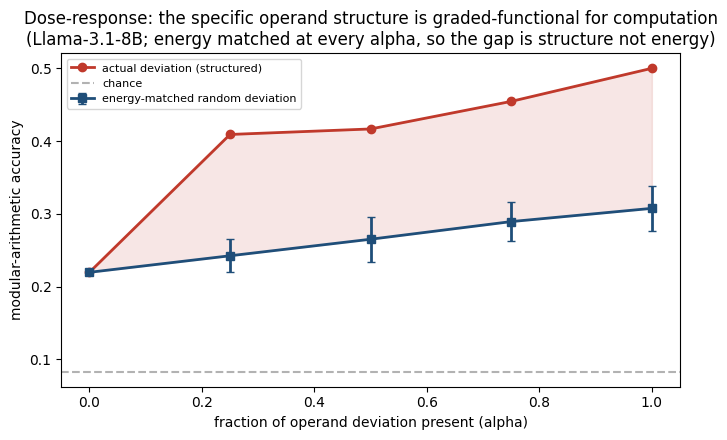

In [ ]:
"""
DOSE-RESPONSE on the confirmed-working Llama setup. Sweeps alpha (fraction of deviation
present) for BOTH the real deviation and energy-matched random. Two curves; gap between
them at each alpha = structure (energy is matched at every alpha). Same positive control
in front. Builds on the run that gave gap=+0.194, z=6.9.
"""
import numpy as np, torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MONTHS=["January","February","March","April","May","June","July","August","September","October","November","December"]
MODEL="meta-llama/Llama-3.1-8B"
GOOD_PROMPT = lambda s,o: f"{MONTHS[s]} plus {o} months is"
ALPHAS=[0.0, 0.25, 0.5, 0.75, 1.0]
N_RANDOM_SEEDS=5

device="cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading {MODEL}...")
model=AutoModelForCausalLM.from_pretrained(MODEL, dtype=torch.float16).to(device); model.eval()
tok=AutoTokenizer.from_pretrained(MODEL)
if tok.pad_token is None: tok.pad_token=tok.eos_token
tok.padding_side="left"

in_emb=model.get_input_embeddings(); out=model.get_output_embeddings()
if out is not None and in_emb.weight.data_ptr()==out.weight.data_ptr():
    h=torch.nn.Linear(in_emb.weight.shape[1],in_emb.weight.shape[0],bias=False).to(device).half()
    with torch.no_grad(): h.weight.copy_(in_emb.weight.detach().clone())
    model.set_output_embeddings(h)

unspaced_ids=[tok(w, add_special_tokens=False)["input_ids"][0] for w in MONTHS]   # ablate (operand)
spaced_ids  =[tok(" "+w, add_special_tokens=False)["input_ids"][0] for w in MONTHS] # score (answer)
print(f"  [CHECK] ablate ids {unspaced_ids[:3]}, score ids {spaced_ids[:3]}")

def fourier_projectors(n):
    j=np.arange(n); P={}
    for k in range(n//2+1):
        c=np.cos(2*np.pi*k*j/n); s=np.sin(2*np.pi*k*j/n)
        cols=[c]+([s] if np.linalg.norm(s)>1e-12 else [])
        B=np.stack(cols,1); B,_=np.linalg.qr(B); P[k]=B@B.T
    return P
P=fourier_projectors(12)
Wpristine=in_emb.weight.detach()[unspaced_ids].float().cpu().numpy().copy()
circle=(P[0]+P[1])@Wpristine; real_dev=Wpristine-circle; nz=[k for k in P if k>=2]

def randomized_dev(seed):
    r=np.random.default_rng(seed); o=np.zeros_like(Wpristine)
    for k in nz:
        re=np.linalg.norm(P[k]@real_dev,'fro'); Rk=P[k]@r.standard_normal(Wpristine.shape)
        if np.linalg.norm(Rk)>1e-9: o+=Rk/np.linalg.norm(Rk)*re
    return o

def write_rows(M_fp32):
    emb=model.get_input_embeddings().weight
    t=torch.tensor(M_fp32, dtype=emb.dtype, device=emb.device)
    with torch.no_grad(): emb.data.index_copy_(0, torch.tensor(unspaced_ids,device=emb.device), t)
    assert np.abs(emb.data[unspaced_ids].float().cpu().numpy()-M_fp32).max()<1e-2, "write didn't land"
def restore(): write_rows(Wpristine)

PAIRS=[(s,o) for s in range(12) for o in range(1,12)]
@torch.no_grad()
def accuracy(batch_size=16):
    prompts=[GOOD_PROMPT(s,o) for s,o in PAIRS]; answers=[(s+o)%12 for s,o in PAIRS]
    correct=0
    for i in range(0,len(prompts),batch_size):
        chunk=prompts[i:i+batch_size]; ans=answers[i:i+batch_size]
        enc=tok(chunk,return_tensors="pt",padding=True).to(device)
        logits=model(**enc).logits[:,-1,:]
        preds=logits[:,spaced_ids].argmax(-1).cpu().numpy()
        correct+=int(np.sum(preds==np.array(ans)))
    return correct/len(prompts)

# baseline + positive control (same gate as before)
restore(); base=accuracy()
write_rows(np.zeros_like(Wpristine)); acc_zero=accuracy(); restore()
print(f"  baseline={base:.3f}  [POS-CONTROL] zeroed={acc_zero:.3f}  "
      f"-> {'PASS' if abs(acc_zero-base)>=0.05 else '*** FAIL — STOP ***'}")
if abs(acc_zero-base)<0.05: raise SystemExit

# ===== DOSE-RESPONSE: REAL curve =====
print(f"\n  {'='*56}\n  DOSE-RESPONSE  (alpha = fraction of deviation present)")
print(f"  {'alpha':>6} {'REAL accuracy':>15} {'RANDOM accuracy (mean±sd)':>28}")
real_curve=[]; rand_curve=[]; rand_sd=[]
for a in ALPHAS:
    # REAL: circle + a*real_dev
    write_rows(circle + a*real_dev); ar=accuracy(); restore(); real_curve.append(ar)
    # RANDOM: circle + a*randomized_dev, averaged over seeds (energy-matched at this alpha)
    rs=[]
    for s in range(N_RANDOM_SEEDS):
        write_rows(circle + a*randomized_dev(s)); rs.append(accuracy()); restore()
    rand_curve.append(np.mean(rs)); rand_sd.append(np.std(rs))
    print(f"  {a:>6.2f} {ar:>15.3f} {np.mean(rs):>18.3f} ± {np.std(rs):.3f}")

print(f"\n  REAL curve:   {[round(x,3) for x in real_curve]}")
print(f"  RANDOM curve: {[round(x,3) for x in rand_curve]}")
# monotonicity check on the REAL curve
mono = all(real_curve[i+1] >= real_curve[i]-0.02 for i in range(len(real_curve)-1))
print(f"  REAL curve monotonic increasing (within 0.02 tol): {mono}")
print(f"  gap at alpha=1 (real - random): {real_curve[-1]-rand_curve[-1]:+.3f}")
print(f"  gap at alpha=0.5: {real_curve[2]-rand_curve[2]:+.3f}")

# ===== save the figure =====
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(7,4.5))
ax.plot(ALPHAS, real_curve, marker='o', lw=2, color='#c0392b', label='actual deviation (structured)')
ax.errorbar(ALPHAS, rand_curve, yerr=rand_sd, marker='s', lw=2, color='#1f4e79', capsize=3,
            label='energy-matched random deviation')
ax.axhline(1/12, ls='--', color='gray', alpha=0.6, label='chance')
ax.fill_between(ALPHAS, rand_curve, real_curve, where=[r>=rn for r,rn in zip(real_curve,rand_curve)],
                alpha=0.12, color='#c0392b')
ax.set_xlabel('fraction of operand deviation present (alpha)')
ax.set_ylabel('modular-arithmetic accuracy')
ax.set_title('Dose-response: the specific operand structure is graded-functional for computation\n'
             '(Llama-3.1-8B; energy matched at every alpha, so the gap is structure not energy)')
ax.legend(fontsize=8); fig.tight_layout()
fig.savefig('dose_response_llama.png', dpi=150, bbox_inches='tight')
print("\n  saved dose_response_llama.png")

In [ ]:
"""
Baseline-gate sweep for a SECOND model (replication). No ablation yet — just find which
model+phrasing does month modular arithmetic above 0.40. Run the full ablation only on a
clear winner. Different-family models (Mistral, Qwen) are the strongest replication of Llama.
"""
import numpy as np, torch, gc
from transformers import AutoModelForCausalLM, AutoTokenizer

MONTHS=["January","February","March","April","May","June","July","August","September","October","November","December"]

# different-family candidates (independent replication); sizes that fit the 42GB GPU in fp16
CANDIDATES = [
    "mistralai/Mistral-7B-v0.3",     # got 0.348 before — try to rescue with better prompts
    "Qwen/Qwen2.5-7B",               # different family, strong at arithmetic
    "Qwen/Qwen2.5-14B",              # bigger, fits in 42GB fp16, likely clears gate
]

PHRASINGS = {
    "A: X plus N months is":            lambda s,o: f"{MONTHS[s]} plus {o} months is",
    "B: N months after X is":           lambda s,o: f"{o} months after {MONTHS[s]} is",
    "C: X + N months =":                lambda s,o: f"{MONTHS[s]} + {o} months =",
    "D: counting N from X":             lambda s,o: f"Counting {o} months from {MONTHS[s]} gives",
    "E: Q/A":                           lambda s,o: f"Q: What month is {o} months after {MONTHS[s]}? A:",
    "F: X, then N months later:":       lambda s,o: f"{MONTHS[s]}, then {o} months later, is",
}
PAIRS=[(s,o) for s in range(12) for o in range(1,12)]
chance=1/12

def test_model(model_name):
    print(f"\n{'='*64}\n# {model_name}\n{'='*64}")
    device="cuda" if torch.cuda.is_available() else "cpu"
    try:
        model=AutoModelForCausalLM.from_pretrained(model_name, dtype=torch.float16).to(device); model.eval()
        tok=AutoTokenizer.from_pretrained(model_name)
    except Exception as e:
        print(f"  could not load: {e}"); return None
    if tok.pad_token is None: tok.pad_token=tok.eos_token
    tok.padding_side="left"
    spaced_ids=[tok(" "+w,add_special_tokens=False)["input_ids"][0] for w in MONTHS]

    @torch.no_grad()
    def accuracy(pf, batch_size=24):
        prompts=[pf(s,o) for s,o in PAIRS]; answers=[(s+o)%12 for s,o in PAIRS]; correct=0
        for i in range(0,len(prompts),batch_size):
            chunk=prompts[i:i+batch_size]; ans=answers[i:i+batch_size]
            enc=tok(chunk,return_tensors="pt",padding=True).to(device)
            logits=model(**enc).logits[:,-1,:]
            preds=logits[:,spaced_ids].argmax(-1).cpu().numpy()
            correct+=int(np.sum(preds==np.array(ans)))
        return correct/len(prompts)

    best=(0,None)
    for name,pf in PHRASINGS.items():
        a=accuracy(pf)
        flag=" <-- clears 0.40" if a>=0.40 else ""
        print(f"  [{name}] acc={a:.3f}{flag}")
        if a>best[0]: best=(a,name)
    print(f"  BEST: {best[1]} = {best[0]:.3f}  -> {'USABLE for ablation' if best[0]>=0.40 else 'below gate'}")
    del model; gc.collect(); torch.cuda.empty_cache()
    return {"model":model_name, "best_acc":best[0], "best_phrasing":best[1]}

results=[]
for m in CANDIDATES:
    try: r=test_model(m)
    except torch.cuda.OutOfMemoryError: print(f"  OOM on {m}"); torch.cuda.empty_cache(); continue
    except Exception as e: print(f"  error on {m}: {e}"); continue
    if r: results.append(r)

print(f"\n{'='*64}\nSUMMARY (which second model can replicate)\n{'='*64}")
for r in sorted(results, key=lambda x:-x["best_acc"]):
    usable = "USABLE" if r["best_acc"]>=0.40 else "too low"
    print(f"  {r['model']}: best={r['best_acc']:.3f} ({r['best_phrasing']}) -> {usable}")
print("\nNext: run the full ablation on the best USABLE model, using its best phrasing.")


# mistralai/Mistral-7B-v0.3


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  [A: X plus N months is] acc=0.348
  [B: N months after X is] acc=0.030
  [C: X + N months =] acc=0.144
  [D: counting N from X] acc=0.242
  [E: Q/A] acc=0.462 <-- clears 0.40
  [F: X, then N months later:] acc=0.091
  BEST: E: Q/A = 0.462  -> USABLE for ablation

# Qwen/Qwen2.5-7B


config.json:   0%|          | 0.00/686 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/27.8k [00:00<?, ?B/s]

...

  [A: X plus N months is] acc=0.394
  [B: N months after X is] acc=0.591 <-- clears 0.40
  [C: X + N months =] acc=0.318
  [D: counting N from X] acc=0.242
  [E: Q/A] acc=0.553 <-- clears 0.40
  [F: X, then N months later:] acc=0.053
  BEST: B: N months after X is = 0.591  -> USABLE for ablation

# Qwen/Qwen2.5-14B


config.json:   0%|          | 0.00/664 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/47.5k [00:00<?, ?B/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

  could not load: Task error: File reconstruction error: IO Error: No space left on device (os error 28)

SUMMARY (which second model can replicate)
  Qwen/Qwen2.5-7B: best=0.591 (B: N months after X is) -> USABLE
  mistralai/Mistral-7B-v0.3: best=0.462 (E: Q/A) -> USABLE

Next: run the full ablation on the best USABLE model, using its best phrasing.


Loading Qwen/Qwen2.5-7B...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

  [CHECK] operand ids as used in prompt: [6058, 7400, 5470, 5813] -> [' January', ' February', ' March', ' April']
  [CHECK] answer ids (score): [6058, 7400, 5470, 5813] -> [' January', ' February', ' March', ' April']
  [CHECK] operand months k=1 circle: frac=0.233, rotation-null p=0.0005

  baseline=0.583  [POS-CONTROL] zeroed operand=0.083  -> PASS
  [CHECK] control preserves circle: 1.16e-15
  [CHECK V1] round-trip=0.583 vs base 0.583 -> PASS

  SINGLE-POINT GAP:
    actual=0.583  random=0.291±0.022  circle-only=0.318  chance=0.083
    seed values: [0.258, 0.318, 0.28, 0.288, 0.311]
    actual − random = +0.292  (z ≈ 13.4)

  DOSE-RESPONSE:
   alpha     REAL       RANDOM (mean±sd)
    0.00    0.318          0.318 ± 0.000
    0.25    0.538          0.318 ± 0.008
    0.50    0.568          0.317 ± 0.010
    0.75    0.576          0.315 ± 0.016
    1.00    0.583          0.309 ± 0.010

  REAL:   [0.318, 0.538, 0.568, 0.576, 0.583]
  RANDOM: [np.float64(0.318), np.float64(0.318), np.fl

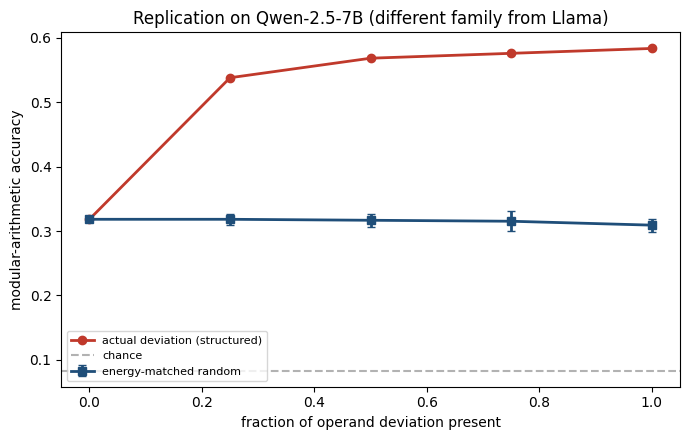

In [ ]:
"""
REPLICATION: full ablation (single-point gap + dose-response) on Qwen-2.5-7B (different
family from Llama). Phrasing B ('N months after X is', baseline 0.591). Handles Qwen's
tokenizer correctly: detects which operand token id the prompt ACTUALLY uses (don't assume
spaced/unspaced), ablates THAT, scores answers among the matching month ids. Positive
control + read-back assert + circle check, all carried from the working Llama run.
"""
import numpy as np, torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MONTHS=["January","February","March","April","May","June","July","August","September","October","November","December"]
MODEL="Qwen/Qwen2.5-7B"
PROMPT = lambda s,o: f"{o} months after {MONTHS[s]} is"   # phrasing B, gave 0.591
ALPHAS=[0.0,0.25,0.5,0.75,1.0]
N_RANDOM_SEEDS=5

device="cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading {MODEL}...")
model=AutoModelForCausalLM.from_pretrained(MODEL, dtype=torch.float16).to(device); model.eval()
tok=AutoTokenizer.from_pretrained(MODEL)
if tok.pad_token is None: tok.pad_token=tok.eos_token
tok.padding_side="left"

in_emb=model.get_input_embeddings(); out=model.get_output_embeddings()
if out is not None and in_emb.weight.data_ptr()==out.weight.data_ptr():
    h=torch.nn.Linear(in_emb.weight.shape[1],in_emb.weight.shape[0],bias=False).to(device).half()
    with torch.no_grad(): h.weight.copy_(in_emb.weight.detach().clone())
    model.set_output_embeddings(h)

# ===== CRITICAL: detect which operand token id the PROMPT actually uses (don't assume) =====
# Tokenize a sample prompt, find the month token in it, per month.
def operand_id_in_prompt(month_idx):
    """Return the token id used for this month AS IT APPEARS in the prompt (offset fixed, month varies)."""
    # build a prompt, tokenize, find which token decodes to the month (or starts it)
    prompt=PROMPT(month_idx, 5)
    ids=tok(prompt, add_special_tokens=False)["input_ids"]
    toks=[tok.decode([i]) for i in ids]
    # find the token whose decode matches the month (with or without leading space)
    target=MONTHS[month_idx]
    for tid,td in zip(ids,toks):
        if td.strip()==target or td.strip()==target[:len(td.strip())] and len(td.strip())>=3:
            return tid
    return None

operand_ids=[operand_id_in_prompt(i) for i in range(12)]
print(f"  [CHECK] operand ids as used in prompt: {operand_ids[:4]} -> {[tok.decode([i]) if i else None for i in operand_ids][:4]}")
if any(i is None for i in operand_ids):
    print("  *** could not locate some month tokens in the prompt; months may be multi-token in Qwen. STOP, send me this. ***")
    # show the tokenization so we can debug
    for mi in range(3):
        print(f"    '{PROMPT(mi,5)}' -> {[tok.decode([i]) for i in tok(PROMPT(mi,5),add_special_tokens=False)['input_ids']]}")
    raise SystemExit

# answer ids: the answer follows "is", a spaced continuation. Find the id for " <Month>".
answer_ids=[tok(" "+w, add_special_tokens=False)["input_ids"][0] for w in MONTHS]
print(f"  [CHECK] answer ids (score): {answer_ids[:4]} -> {[tok.decode([i]) for i in answer_ids][:4]}")

# ===== verify the operand rows carry a circle =====
def fourier_projectors(n):
    j=np.arange(n); P={}
    for k in range(n//2+1):
        c=np.cos(2*np.pi*k*j/n); s=np.sin(2*np.pi*k*j/n)
        cols=[c]+([s] if np.linalg.norm(s)>1e-12 else [])
        B=np.stack(cols,1); B,_=np.linalg.qr(B); P[k]=B@B.T
    return P
P=fourier_projectors(12)
W_op=in_emb.weight.detach()[operand_ids].float().cpu().numpy().copy()
def haar(n,rng): A=rng.standard_normal((n,n)); Q,R=np.linalg.qr(A); return Q*np.sign(np.diag(R))
Wc=W_op-(P[0]@W_op)
def frac(M,k): return np.linalg.norm(P[k]@M,'fro')**2/np.linalg.norm(M,'fro')**2
obs=frac(Wc,1); rng=np.random.default_rng(0); ge=1
for _ in range(2000):
    if frac(haar(12,rng)@Wc,1)>=obs: ge+=1
print(f"  [CHECK] operand months k=1 circle: frac={obs:.3f}, rotation-null p={ge/2001:.4f}")
if ge/2001>0.05:
    print("  *** operand rows lack a significant circle; ablation object unclear. STOP, send me this. ***")
    raise SystemExit

# ===== edit/score machinery =====
def write_rows(M_fp32):
    emb=model.get_input_embeddings().weight
    t=torch.tensor(M_fp32, dtype=emb.dtype, device=emb.device)
    with torch.no_grad(): emb.data.index_copy_(0, torch.tensor(operand_ids,device=emb.device), t)
    assert np.abs(emb.data[operand_ids].float().cpu().numpy()-M_fp32).max()<1e-2, "write didn't land"
Wpristine=W_op.copy()
def restore(): write_rows(Wpristine)

PAIRS=[(s,o) for s in range(12) for o in range(1,12)]
@torch.no_grad()
def accuracy(batch_size=16):
    prompts=[PROMPT(s,o) for s,o in PAIRS]; answers=[(s+o)%12 for s,o in PAIRS]; correct=0
    for i in range(0,len(prompts),batch_size):
        chunk=prompts[i:i+batch_size]; ans=answers[i:i+batch_size]
        enc=tok(chunk,return_tensors="pt",padding=True).to(device)
        logits=model(**enc).logits[:,-1,:]
        preds=logits[:,answer_ids].argmax(-1).cpu().numpy()
        correct+=int(np.sum(preds==np.array(ans)))
    return correct/len(prompts)

restore(); base=accuracy()
write_rows(np.zeros_like(Wpristine)); acc_zero=accuracy(); restore()
print(f"\n  baseline={base:.3f}  [POS-CONTROL] zeroed operand={acc_zero:.3f}  "
      f"-> {'PASS' if abs(acc_zero-base)>=0.05 else '*** FAIL — STOP ***'}")
if abs(acc_zero-base)<0.05: raise SystemExit

# ===== single-point gap =====
W=Wpristine.copy(); circle=(P[0]+P[1])@W; real_dev=W-circle; nz=[k for k in P if k>=2]
def randomized(seed):
    r=np.random.default_rng(seed); o=circle.copy()
    for k in nz:
        re=np.linalg.norm(P[k]@real_dev,'fro'); Rk=P[k]@r.standard_normal(W.shape)
        if np.linalg.norm(Rk)>1e-9: o+=Rk/np.linalg.norm(Rk)*re
    return o
print(f"  [CHECK] control preserves circle: {np.linalg.norm((P[0]+P[1])@W-(P[0]+P[1])@randomized(0)):.2e}")
write_rows(circle+real_dev); rt=accuracy(); restore()
print(f"  [CHECK V1] round-trip={rt:.3f} vs base {base:.3f} -> {'PASS' if abs(rt-base)<0.02 else 'FAIL'}")

restore(); acc_actual=accuracy()
write_rows(circle); acc_none=accuracy(); restore()
rand=[]
for s in range(N_RANDOM_SEEDS): write_rows(randomized(s)); rand.append(accuracy()); restore()
rm,rsd=np.mean(rand),np.std(rand); gap=acc_actual-rm; z=gap/rsd if rsd>1e-9 else float('inf')
print(f"\n  SINGLE-POINT GAP:")
print(f"    actual={acc_actual:.3f}  random={rm:.3f}±{rsd:.3f}  circle-only={acc_none:.3f}  chance={1/12:.3f}")
print(f"    seed values: {[round(x,3) for x in rand]}")
print(f"    actual − random = {gap:+.3f}  (z ≈ {z:.1f})")

# ===== dose-response =====
print(f"\n  DOSE-RESPONSE:")
print(f"  {'alpha':>6} {'REAL':>8} {'RANDOM (mean±sd)':>22}")
real_curve=[]; rand_curve=[]; rand_sd=[]
for a in ALPHAS:
    write_rows(circle+a*real_dev); ar=accuracy(); restore(); real_curve.append(ar)
    rs=[]
    for s in range(N_RANDOM_SEEDS): write_rows(circle+a*randomized(s)); rs.append(accuracy()); restore()
    rand_curve.append(np.mean(rs)); rand_sd.append(np.std(rs))
    print(f"  {a:>6.2f} {ar:>8.3f} {np.mean(rs):>14.3f} ± {np.std(rs):.3f}")
mono=all(real_curve[i+1]>=real_curve[i]-0.02 for i in range(len(real_curve)-1))
print(f"\n  REAL:   {[round(x,3) for x in real_curve]}")
print(f"  RANDOM: {[round(x,3) for x in rand_curve]}")
print(f"  REAL monotonic: {mono}   gap@1.0: {real_curve[-1]-rand_curve[-1]:+.3f}   gap@0.5: {real_curve[2]-rand_curve[2]:+.3f}")

import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(7,4.5))
ax.plot(ALPHAS, real_curve, marker='o', lw=2, color='#c0392b', label='actual deviation (structured)')
ax.errorbar(ALPHAS, rand_curve, yerr=rand_sd, marker='s', lw=2, color='#1f4e79', capsize=3, label='energy-matched random')
ax.axhline(1/12, ls='--', color='gray', alpha=0.6, label='chance')
ax.set_xlabel('fraction of operand deviation present'); ax.set_ylabel('modular-arithmetic accuracy')
ax.set_title('Replication on Qwen-2.5-7B (different family from Llama)')
ax.legend(fontsize=8); fig.tight_layout(); fig.savefig('dose_response_qwen.png',dpi=150,bbox_inches='tight')
print("  saved dose_response_qwen.png")

In [ ]:
"""
PER-MODE ATTRIBUTION on Qwen-2.5-7B: which higher modes (k>=2) carry the computational function?
Two experiments per mode:
  KNOCK-OUT (necessity): remove ONLY mode k (vs energy-matched random replacement)
  ADD-ONE (sufficiency): circle + ONLY mode k (vs circle + energy-matched random in mode k)
Same verified machinery: operand-id detection, positive control, read-back assert.
"""
import numpy as np, torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MONTHS=["January","February","March","April","May","June","July","August","September","October","November","December"]
MODEL="Qwen/Qwen2.5-7B"
PROMPT = lambda s,o: f"{o} months after {MONTHS[s]} is"
N_SEEDS=5

device="cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading {MODEL}...")
model=AutoModelForCausalLM.from_pretrained(MODEL, dtype=torch.float16).to(device); model.eval()
tok=AutoTokenizer.from_pretrained(MODEL)
if tok.pad_token is None: tok.pad_token=tok.eos_token
tok.padding_side="left"
in_emb=model.get_input_embeddings(); out=model.get_output_embeddings()
if out is not None and in_emb.weight.data_ptr()==out.weight.data_ptr():
    h=torch.nn.Linear(in_emb.weight.shape[1],in_emb.weight.shape[0],bias=False).to(device).half()
    with torch.no_grad(): h.weight.copy_(in_emb.weight.detach().clone())
    model.set_output_embeddings(h)

def operand_id(mi):
    ids=tok(PROMPT(mi,5),add_special_tokens=False)["input_ids"]
    for tid in ids:
        if tok.decode([tid]).strip()==MONTHS[mi]: return tid
    return None
operand_ids=[operand_id(i) for i in range(12)]
answer_ids=[tok(" "+w,add_special_tokens=False)["input_ids"][0] for w in MONTHS]
assert all(i is not None for i in operand_ids), "month token not found in prompt"
print(f"  [CHECK] operand ids {operand_ids[:3]} -> {[tok.decode([i]) for i in operand_ids][:3]}")

def fourier_projectors(n):
    j=np.arange(n); P={}
    for k in range(n//2+1):
        c=np.cos(2*np.pi*k*j/n); s=np.sin(2*np.pi*k*j/n)
        cols=[c]+([s] if np.linalg.norm(s)>1e-12 else [])
        B=np.stack(cols,1); B,_=np.linalg.qr(B); P[k]=B@B.T
    return P
P=fourier_projectors(12)
Wpristine=in_emb.weight.detach()[operand_ids].float().cpu().numpy().copy()
HIGHER=[k for k in P if k>=2]   # k=2..6

def write_rows(M):
    emb=model.get_input_embeddings().weight
    t=torch.tensor(M, dtype=emb.dtype, device=emb.device)
    with torch.no_grad(): emb.data.index_copy_(0, torch.tensor(operand_ids,device=emb.device), t)
    assert np.abs(emb.data[operand_ids].float().cpu().numpy()-M).max()<1e-2
def restore(): write_rows(Wpristine)

PAIRS=[(s,o) for s in range(12) for o in range(1,12)]
@torch.no_grad()
def accuracy(bs=16):
    prompts=[PROMPT(s,o) for s,o in PAIRS]; answers=[(s+o)%12 for s,o in PAIRS]; c=0
    for i in range(0,len(prompts),bs):
        ch=prompts[i:i+bs]; an=answers[i:i+bs]
        enc=tok(ch,return_tensors="pt",padding=True).to(device)
        pr=model(**enc).logits[:,-1,:][:,answer_ids].argmax(-1).cpu().numpy()
        c+=int(np.sum(pr==np.array(an)))
    return c/len(prompts)

W=Wpristine.copy(); circle=(P[0]+P[1])@W; real_dev=W-circle

# positive control gate
restore(); base=accuracy()
write_rows(np.zeros_like(W)); az=accuracy(); restore()
print(f"  baseline={base:.3f}  [POS-CONTROL] zeroed={az:.3f} -> {'PASS' if abs(az-base)>=0.05 else 'FAIL-STOP'}")
if abs(az-base)<0.05: raise SystemExit

def rand_in_mode(k, seed):
    """energy-matched random content confined to mode k"""
    r=np.random.default_rng(seed)
    e=np.linalg.norm(P[k]@real_dev,'fro'); Rk=P[k]@r.standard_normal(W.shape)
    return Rk/np.linalg.norm(Rk)*e if np.linalg.norm(Rk)>1e-9 else np.zeros_like(W)

print(f"\n  per-mode energy (fraction of deviation):")
totdev=np.linalg.norm(real_dev)**2
for k in HIGHER: print(f"    k={k}: {np.linalg.norm(P[k]@real_dev)**2/totdev:.3f}")

# ===== KNOCK-OUT: remove only mode k (real removed) vs random-replaced =====
print(f"\n  {'='*60}\n  KNOCK-OUT (necessity): accuracy with mode k REMOVED")
print(f"  baseline (all present) = {base:.3f}")
print(f"  {'mode':>5} {'k removed':>12} {'k->random (mean±sd)':>22} {'necessity drop':>15}")
for k in HIGHER:
    # remove mode k entirely: W - P_k W
    write_rows(W - P[k]@W); acc_removed=accuracy(); restore()
    # control: replace mode k with energy-matched random (so energy is back, structure isn't)
    rs=[]
    for s in range(N_SEEDS):
        write_rows(W - P[k]@W + rand_in_mode(k,s)); rs.append(accuracy()); restore()
    drop = base - acc_removed
    print(f"  k={k:>2} {acc_removed:>12.3f} {np.mean(rs):>14.3f} ± {np.std(rs):.3f} {drop:>+15.3f}")

# ===== ADD-ONE: circle + only mode k (real) vs circle + only mode k (random) =====
print(f"\n  {'='*60}\n  ADD-ONE (sufficiency): accuracy with circle + ONLY mode k")
print(f"  circle-only floor = ", end="")
write_rows(circle); floor=accuracy(); restore(); print(f"{floor:.3f}   full={base:.3f}")
print(f"  {'mode':>5} {'circle+k(real)':>15} {'circle+k(random) (mean±sd)':>28} {'sufficiency':>12}")
for k in HIGHER:
    write_rows(circle + P[k]@real_dev); acc_real=accuracy(); restore()
    rs=[]
    for s in range(N_SEEDS):
        write_rows(circle + rand_in_mode(k,s)); rs.append(accuracy()); restore()
    suff = (acc_real - floor)/(base - floor) if base>floor else 0   # fraction of full effect recovered
    print(f"  k={k:>2} {acc_real:>15.3f} {np.mean(rs):>20.3f} ± {np.std(rs):.3f} {suff:>11.1%}")

print(f"\n  READ: KNOCK-OUT shows which modes are NECESSARY (large drop when removed, and the")
print(f"  drop is structure-specific if random-replacement doesn't restore it).")
print(f"  ADD-ONE shows which are SUFFICIENT (circle+that mode alone recovers much of the effect,")
print(f"  and real >> random for that mode). A mode high on BOTH is the carrier.")

Loading Qwen/Qwen2.5-7B...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

  [CHECK] operand ids [6058, 7400, 5470] -> [' January', ' February', ' March']
  baseline=0.583  [POS-CONTROL] zeroed=0.083 -> PASS

  per-mode energy (fraction of deviation):
    k=2: 0.237
    k=3: 0.224
    k=4: 0.218
    k=5: 0.217
    k=6: 0.104

  KNOCK-OUT (necessity): accuracy with mode k REMOVED
  baseline (all present) = 0.583
   mode    k removed    k->random (mean±sd)  necessity drop
  k= 2        0.583          0.594 ± 0.006          +0.000
  k= 3        0.583          0.580 ± 0.004          +0.000
  k= 4        0.583          0.585 ± 0.006          +0.000
  k= 5        0.568          0.571 ± 0.008          +0.015
  k= 6        0.576          0.582 ± 0.009          +0.008

  ADD-ONE (sufficiency): accuracy with circle + ONLY mode k
  circle-only floor = 0.318   full=0.583
   mode  circle+k(real)   circle+k(random) (mean±sd)  sufficiency
  k= 2           0.394                0.291 ± 0.006       28.6%
  k= 3           0.439                0.298 ± 0.008       45.7%
  k= 4   

In [ ]:
"""
PER-MODE ATTRIBUTION on Llama-3.1-8B (replication of the Qwen per-mode analysis).
Same experiment: knock-out (necessity) + add-one (sufficiency), per-mode energy-matched
controls. Prompt 'X plus N months is' (baseline 0.500). Question: does Llama show the same
redundant + rising-sufficiency-toward-high-k pattern Qwen did (peak at k=5)?
"""
import numpy as np, torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MONTHS=["January","February","March","April","May","June","July","August","September","October","November","December"]
MODEL="meta-llama/Llama-3.1-8B"
PROMPT = lambda s,o: f"{MONTHS[s]} plus {o} months is"
N_SEEDS=5

device="cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading {MODEL}...")
model=AutoModelForCausalLM.from_pretrained(MODEL, dtype=torch.float16).to(device); model.eval()
tok=AutoTokenizer.from_pretrained(MODEL)
if tok.pad_token is None: tok.pad_token=tok.eos_token
tok.padding_side="left"
in_emb=model.get_input_embeddings(); out=model.get_output_embeddings()
if out is not None and in_emb.weight.data_ptr()==out.weight.data_ptr():
    h=torch.nn.Linear(in_emb.weight.shape[1],in_emb.weight.shape[0],bias=False).to(device).half()
    with torch.no_grad(): h.weight.copy_(in_emb.weight.detach().clone())
    model.set_output_embeddings(h)

def operand_id(mi):
    ids=tok(PROMPT(mi,5),add_special_tokens=False)["input_ids"]
    for tid in ids:
        if tok.decode([tid]).strip()==MONTHS[mi]: return tid
    return None
operand_ids=[operand_id(i) for i in range(12)]
answer_ids=[tok(" "+w,add_special_tokens=False)["input_ids"][0] for w in MONTHS]
assert all(i is not None for i in operand_ids), "month token not found in prompt"
print(f"  [CHECK] operand ids {operand_ids[:3]} -> {[tok.decode([i]) for i in operand_ids][:3]}")

def fourier_projectors(n):
    j=np.arange(n); P={}
    for k in range(n//2+1):
        c=np.cos(2*np.pi*k*j/n); s=np.sin(2*np.pi*k*j/n)
        cols=[c]+([s] if np.linalg.norm(s)>1e-12 else [])
        B=np.stack(cols,1); B,_=np.linalg.qr(B); P[k]=B@B.T
    return P
P=fourier_projectors(12)
Wpristine=in_emb.weight.detach()[operand_ids].float().cpu().numpy().copy()
HIGHER=[k for k in P if k>=2]

def write_rows(M):
    emb=model.get_input_embeddings().weight
    t=torch.tensor(M, dtype=emb.dtype, device=emb.device)
    with torch.no_grad(): emb.data.index_copy_(0, torch.tensor(operand_ids,device=emb.device), t)
    assert np.abs(emb.data[operand_ids].float().cpu().numpy()-M).max()<1e-2
def restore(): write_rows(Wpristine)

PAIRS=[(s,o) for s in range(12) for o in range(1,12)]
@torch.no_grad()
def accuracy(bs=16):
    prompts=[PROMPT(s,o) for s,o in PAIRS]; answers=[(s+o)%12 for s,o in PAIRS]; c=0
    for i in range(0,len(prompts),bs):
        ch=prompts[i:i+bs]; an=answers[i:i+bs]
        enc=tok(ch,return_tensors="pt",padding=True).to(device)
        pr=model(**enc).logits[:,-1,:][:,answer_ids].argmax(-1).cpu().numpy()
        c+=int(np.sum(pr==np.array(an)))
    return c/len(prompts)

W=Wpristine.copy(); circle=(P[0]+P[1])@W; real_dev=W-circle
restore(); base=accuracy()
write_rows(np.zeros_like(W)); az=accuracy(); restore()
print(f"  baseline={base:.3f}  [POS-CONTROL] zeroed={az:.3f} -> {'PASS' if abs(az-base)>=0.05 else 'FAIL-STOP'}")
if abs(az-base)<0.05: raise SystemExit

def rand_in_mode(k, seed):
    r=np.random.default_rng(seed)
    e=np.linalg.norm(P[k]@real_dev,'fro'); Rk=P[k]@r.standard_normal(W.shape)
    return Rk/np.linalg.norm(Rk)*e if np.linalg.norm(Rk)>1e-9 else np.zeros_like(W)

print(f"\n  per-mode energy (fraction of deviation):")
totdev=np.linalg.norm(real_dev)**2
for k in HIGHER: print(f"    k={k}: {np.linalg.norm(P[k]@real_dev)**2/totdev:.3f}")

print(f"\n  {'='*60}\n  KNOCK-OUT (necessity): accuracy with mode k REMOVED  (baseline {base:.3f})")
print(f"  {'mode':>5} {'k removed':>12} {'k->random (mean±sd)':>22} {'necessity drop':>15}")
for k in HIGHER:
    write_rows(W - P[k]@W); acc_removed=accuracy(); restore()
    rs=[]
    for s in range(N_SEEDS): write_rows(W - P[k]@W + rand_in_mode(k,s)); rs.append(accuracy()); restore()
    print(f"  k={k:>2} {acc_removed:>12.3f} {np.mean(rs):>14.3f} ± {np.std(rs):.3f} {base-acc_removed:>+15.3f}")

print(f"\n  {'='*60}\n  ADD-ONE (sufficiency): circle + ONLY mode k")
write_rows(circle); floor=accuracy(); restore()
print(f"  circle-only floor = {floor:.3f}   full = {base:.3f}")
print(f"  {'mode':>5} {'circle+k(real)':>15} {'circle+k(random) (mean±sd)':>28} {'sufficiency':>12}")
for k in HIGHER:
    write_rows(circle + P[k]@real_dev); acc_real=accuracy(); restore()
    rs=[]
    for s in range(N_SEEDS): write_rows(circle + rand_in_mode(k,s)); rs.append(accuracy()); restore()
    suff=(acc_real-floor)/(base-floor) if base>floor else 0
    print(f"  k={k:>2} {acc_real:>15.3f} {np.mean(rs):>20.3f} ± {np.std(rs):.3f} {suff:>11.1%}")

print(f"\n  COMPARE TO QWEN: Qwen had no mode necessary (redundant), sufficiency rising")
print(f"  k=2(29%)->k=5(86%), k=6 dropping. Does Llama match this shape and peak?")

Loading meta-llama/Llama-3.1-8B...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  [CHECK] operand ids [33327, 33877, 28623] -> ['January', 'February', 'March']
  baseline=0.500  [POS-CONTROL] zeroed=0.083 -> PASS

  per-mode energy (fraction of deviation):
    k=2: 0.239
    k=3: 0.219
    k=4: 0.221
    k=5: 0.208
    k=6: 0.113

  KNOCK-OUT (necessity): accuracy with mode k REMOVED  (baseline 0.500)
   mode    k removed    k->random (mean±sd)  necessity drop
  k= 2        0.568          0.567 ± 0.029          -0.068
  k= 3        0.470          0.524 ± 0.026          +0.030
  k= 4        0.485          0.509 ± 0.019          +0.015
  k= 5        0.477          0.527 ± 0.008          +0.023
  k= 6        0.545          0.535 ± 0.016          -0.045

  ADD-ONE (sufficiency): circle + ONLY mode k
  circle-only floor = 0.220   full = 0.500
   mode  circle+k(real)   circle+k(random) (mean±sd)  sufficiency
  k= 2           0.311                0.258 ± 0.019       32.4%
  k= 3           0.364                0.233 ± 0.012       51.4%
  k= 4           0.341              

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
MODEL="meta-llama/Llama-3.1-8B"
tok=AutoTokenizer.from_pretrained(MODEL)

# CHECK 1: does " January" (spaced) tokenize differently from how it appears in the prompt?
spaced = tok(" January", add_special_tokens=False)["input_ids"]
prompt = "January plus 5 months is"
enc = tok(prompt, add_special_tokens=False)["input_ids"]
print("'  January' (what we edit):", spaced, "->", [tok.decode([t]) for t in spaced])
print("prompt token ids:", enc)
print("prompt tokens decoded:", [tok.decode([t]) for t in enc])
print()
# find which token in the prompt is the month
print("Is our edited token id", spaced[0], "actually IN the prompt?", spaced[0] in enc)
print()
# CHECK 2: how does sentence-initial 'January' (no space) tokenize?
nospace = tok("January", add_special_tokens=False)["input_ids"]
print("'January' (no space, sentence-initial):", nospace, "->", [tok.decode([t]) for t in nospace])
print("Do spaced and no-space differ?", spaced != nospace)
print()
# CHECK 3: where does the ANSWER month appear? The model predicts the next token after "is".
# What token would "June" be as a continuation? (with leading space, since it follows "is ")
ans = tok(" June", add_special_tokens=False)["input_ids"]
print("answer ' June' (what we score at output):", ans, "->", [tok.decode([t]) for t in ans])

'  January' (what we edit): [6186] -> [' January']
prompt token ids: [33327, 5636, 220, 20, 4038, 374]
prompt tokens decoded: ['January', ' plus', ' ', '5', ' months', ' is']

Is our edited token id 6186 actually IN the prompt? False

'January' (no space, sentence-initial): [33327] -> ['January']
Do spaced and no-space differ? True

answer ' June' (what we score at output): [5651] -> [' June']
